In [1]:
# Useful imports

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import time
import os

from sklearn.model_selection import train_test_split, StratifiedShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.utils import class_weight

from sklearn.datasets import fetch_covtype


import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Input,Dropout
from tensorflow.keras.optimizers import Adam

from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers.schedules import ExponentialDecay


from tensorflow.keras.datasets import fashion_mnist

# utility code

random_seed = 42

def format_hms(seconds):
    return time.strftime("%H:%M:%S", time.gmtime(seconds))

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'  # Suppresses INFO and WARNING messages


I0000 00:00:1789567127.426006    1296 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [ ]:
print("Num GPUs Available:", len(tf.config.list_physical_devices('GPU')))
tf.debugging.set_log_device_placement(True)

In [20]:
# Optional: Show where a tensor is stored
tensor = tf.constant([[1.0, 2.0], [3.0, 4.0]])
print("Tensor is on device:", tensor.device)

Tensor is on device: /job:localhost/replica:0/task:0/device:GPU:0


---

# all premade functions/shortcuts

In [2]:
def plot_learning_curves(hist, title, verbose=True):
    
    val_losses = hist.history['val_loss']
    min_val_loss = min(val_losses)
    min_val_epoch = val_losses.index(min_val_loss)
    val_acc_at_min_loss = hist.history['val_accuracy'][min_val_epoch]

    epochs = range(1, len(val_losses) + 1)  # epoch numbers starting at 1

    fig, axs = plt.subplots(2, 1, figsize=(8, 8), sharex=True)

    # --- Loss Plot ---
    axs[0].plot(epochs, hist.history['loss'], label='train loss', color="#fe53bb", alpha=0.9)
    axs[0].plot(epochs, hist.history['val_loss'], label='val loss', color="#08f7fe", alpha= 1, linewidth = 4  )
    axs[0].plot(epochs, hist.history['val_loss'], label='_nolegend_', color="#343f62", alpha= 0.6, linewidth = 1.3  )
    axs[0].vlines(min_val_epoch + 1, 0, min_val_loss, color='#78290f', linestyles = 'dotted')
    axs[0].hlines(min_val_loss, 0, min_val_epoch + 1, color='#78290f', linestyles = 'dotted')
    axs[0].scatter(min_val_epoch + 1, min_val_loss, color='#78290f', marker='x', s=50, label='min val loss', zorder=4)
    
    axs[0].set_title(f'{title} - Categorical Cross-Entropy Loss')
    axs[0].set_ylabel('Loss')
    axs[0].legend()
    axs[0].grid(True)

    # --- Accuracy Plot ---
    axs[1].plot(epochs, hist.history['val_accuracy'], label='val acc', color="#08f7fe", alpha=1, linewidth = 4)
    axs[1].plot(epochs, hist.history['val_accuracy'], label='_nolegend_', color="#343f62", alpha = 0.6, linewidth = 1.3)
    axs[1].plot(epochs, hist.history['accuracy'], label='train acc', color="#fe53bb", alpha=0.9)
    axs[1].vlines(min_val_epoch + 1, 0, 1, color='#78290f', linestyles = 'dotted')
    axs[1].scatter(min_val_epoch + 1, val_acc_at_min_loss, color='#78290f', marker='x', s=50, label='acc @ min val loss', zorder = 4)
    axs[1].set_title(f'{title} - Accuracy')
    axs[1].set_xlabel('Epoch')
    axs[1].set_ylabel('Accuracy')
    axs[1].legend()
    axs[1].grid(True)
    axs[1].set_ylim(0, 1.05)

    plt.tight_layout()
    plt.show()

    if verbose:
        print(f"Final Training Loss:            {hist.history['loss'][-1]:.4f}")
        print(f"Final Training Accuracy:        {hist.history['accuracy'][-1]:.4f}")
        print(f"Final Validation Loss:          {hist.history['val_loss'][-1]:.4f}")
        print(f"Final Validation Accuracy:      {hist.history['val_accuracy'][-1]:.4f}")
        print(f"Minimum Validation Loss:        {min_val_loss:.4f} (Epoch {min_val_epoch + 1})")
        print(f"Validation Accuracy @ Min Loss: {val_acc_at_min_loss:.4f}")

    results[title] = (val_acc_at_min_loss,min_val_epoch + 1)


In [3]:
results = {}

In [4]:
def print_results():
    for title, (acc, ep) in sorted(results.items(), 
                                   key=lambda kv: kv[1][0],   # kv[1] is (acc, epoch); [0] is acc
                                   reverse=True
                                  ):
        print(f"{title:<40}\t{acc:.4f}")

In [5]:
def train_and_test(model, 
                   epochs        = 500,                   # Just needs to be bigger than early stop point
                   lr_schedule   = 0.001,                 # Adam default / 10 seems to work well for this dataset
                   optimizer     = "Adam",
                   title         = "Learning Curves",
                   batch_size    = 64,                     # experiments confirmed this was optimal with other parameters at default
                   use_early_stopping = True,
                   patience      = 10,                                       
                   min_delta     = 0.0001,                 
                   callbacks     = [],                     # for extra callbacks other than early stopping
                   verbose       = 0,
                   return_history = False
                  ):

    print(f"\n{title}\n")


    if optimizer == "Adam":
        opt = Adam(learning_rate=lr_schedule) 
    else:
        opt = optimizer
    
    #Compiling the model
    model.compile(optimizer=opt, 
                  loss="sparse_categorical_crossentropy", 
                  metrics=["accuracy"]
                 )

    early_stop = EarlyStopping(
        monitor='val_loss',
        patience=patience,
        min_delta=min_delta,
        restore_best_weights=True,               # this will mean that the model which produced the smallest validation loss will be returned
        verbose=verbose
    )
    

    if use_early_stopping:
        cbs=[early_stop] + callbacks
    else:
        cbs=callbacks

    # start timer
    start = time.time()
    
    # Fit the model with early stopping
    history = model.fit(X_train, y_train,
                        epochs=epochs,
                        batch_size=batch_size,
                        validation_data=(X_val, y_val),       # must use stratified validation set
                        callbacks=cbs,
                        verbose=verbose
                       )

    if use_early_stopping:
        best_epoch = early_stop.best_epoch
        best_acc   = history.history['val_accuracy'][best_epoch]
    else:
        best_epoch = np.argmax(history.history['val_accuracy'])
        best_acc   = history.history['val_accuracy'][best_epoch]
    
    # Plot training history
    plot_learning_curves(history, title=title)

    # Evaluate on test data
    test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
    
    print(f"\nTest Loss: {test_loss:.4f}")
    print(f"Test Accuracy: {test_accuracy:.4f}")

    print(f"\nValidation-Test Gap (accuracy): {abs(best_acc - test_accuracy):.6f}")
    
    # Record end time and print execution time
    end = time.time()
    print(f"\nExecution Time: " + format_hms(end-start))

    if return_history:
        return history

In [6]:
def show_counts(name, y_arr):
    c = Counter(y_arr)
    total = sum(c.values())
    print(f"{name}: total={total}, per-class={dict(c)}")

In [7]:
def build_model(n_inputs, layer_list ,n_classes ):
    layers = [ Input(shape=(n_inputs,)) ]
    for (width,act,l2_lambda,dropout_rate) in layer_list:
        layers.append( Dense(width, activation=act, kernel_regularizer=regularizers.l2(l2_lambda)) )
        if dropout_rate > 0:
            layers.append( Dropout(dropout_rate) )
    layers.append( Dense(n_classes, activation='softmax') )
    return models.Sequential( layers )

---

# data

In [8]:
start = time.time(); x, y = fetch_covtype(return_X_y=True)
classes, counts = np.unique(y, return_counts=True)
min_count = 1000

rng = np.random.default_rng(42)

idx_list = []
for c in classes:
    c_idx = np.where(y == c)[0]
    chosen = rng.choice(c_idx, size=min_count, replace=False)
    idx_list.append(chosen)

idx_bal = np.concatenate(idx_list)
rng.shuffle(idx_bal)

X_sub = x[idx_bal]
y_sub = y[idx_bal] - 1  # relabel to {0..6} for keras
print("balanced subset shape:", X_sub.shape, "class counts:", dict(Counter(y_sub)))

#-----
test_size = 0.20
val_size = 0.20  # of the whole dataset

X_trainval, X_test, y_trainval, y_test = train_test_split(
    X_sub, y_sub, test_size=test_size, random_state=random_seed, stratify=y_sub
)
val_size_rel = val_size / (1.0 - test_size)  # e.g., 0.20 / 0.80 = 0.25

X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=val_size_rel, random_state=random_seed, stratify=y_trainval
)

#----
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train).astype(np.float32)
X_val   = scaler.transform(X_val).astype(np.float32)
X_test  = scaler.transform(X_test).astype(np.float32)

print("shapes:", "X_train", X_train.shape, "X_val", X_val.shape, "X_test", X_test.shape)
show_counts("train", y_train)
show_counts("val  ", y_val)
show_counts("test ", y_test)


labels = np.unique(y_train)

n_inputs = X_train.shape[1]

n_classes = len(labels)

end = time.time()
print(f"\nExecution Time: " + format_hms(end-start))

balanced subset shape: (7000, 54) class counts: {np.int32(2): 1000, np.int32(0): 1000, np.int32(4): 1000, np.int32(5): 1000, np.int32(1): 1000, np.int32(3): 1000, np.int32(6): 1000}
shapes: X_train (4200, 54) X_val (1400, 54) X_test (1400, 54)
train: total=4200, per-class={np.int32(2): 600, np.int32(1): 600, np.int32(0): 600, np.int32(3): 600, np.int32(5): 600, np.int32(4): 600, np.int32(6): 600}
val  : total=1400, per-class={np.int32(1): 200, np.int32(6): 200, np.int32(5): 200, np.int32(4): 200, np.int32(3): 200, np.int32(2): 200, np.int32(0): 200}
test : total=1400, per-class={np.int32(0): 200, np.int32(6): 200, np.int32(2): 200, np.int32(3): 200, np.int32(4): 200, np.int32(5): 200, np.int32(1): 200}

Execution Time: 00:00:00


---

# test code

In [9]:
# base_layer = [
#     (64,'relu',0.0,0.0), 
#     (32,'relu',0.001,0.3)
# ]

# model_baseline = build_model(n_inputs, base_layer, n_classes)
# model_baseline_hx = train_and_test(model_baseline, return_history=True)

# model_baseline_hx

In [10]:
# model_baseline_hx.history['loss'][-1]

In [11]:
# min_val_loss = min(model_baseline_hx.history['val_loss'])

# epoch_loc_min_loss = model_baseline_hx.history['val_loss'].index(min_val_loss)

# val_acc_min_loss = (model_baseline_hx.history['val_accuracy'][epoch_loc_min_loss])

# print(min_val_loss)
# print(epoch_loc_min_loss+1)
# print(val_acc_min_loss)

---

# p1

I0000 00:00:1789567132.288601    1296 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 6071 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 2070 SUPER, pci bus id: 0000:01:00.0, compute capability: 7.5



base + relu



I0000 00:00:1789567134.361472    2820 service.cc:153] XLA service 0x7aaf8c033420 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1789567134.361508    2820 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 2070 SUPER, Compute Capability 7.5 (Driver: 13.4.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.25.1)
I0000 00:00:1789567134.385457    2820 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1789567134.535204    2820 cuda_dnn.cc:461] Loaded cuDNN version 92501
I0000 00:00:1789567134.574759    2820 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1438__.17
I0000 00:00:1789567136.186962    2820 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.
I0000 00:00:1789567136.576678    2820 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1438__.1

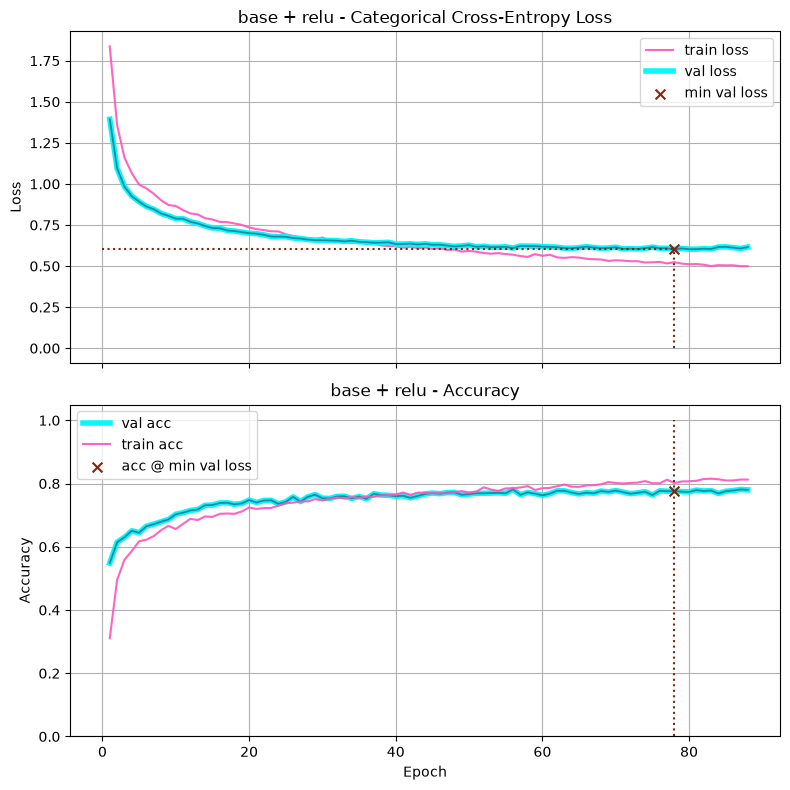

Final Training Loss:            0.4992
Final Training Accuracy:        0.8126
Final Validation Loss:          0.6157
Final Validation Accuracy:      0.7800
Minimum Validation Loss:        0.6015 (Epoch 78)
Validation Accuracy @ Min Loss: 0.7764

Test Loss: 0.6242
Test Accuracy: 0.7643

Validation-Test Gap (accuracy): 0.012143

Execution Time: 00:00:39

base + sigmoid



I0000 00:00:1789567174.484041    2818 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_37331__.17
I0000 00:00:1789567175.940307    2821 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_37331__.17


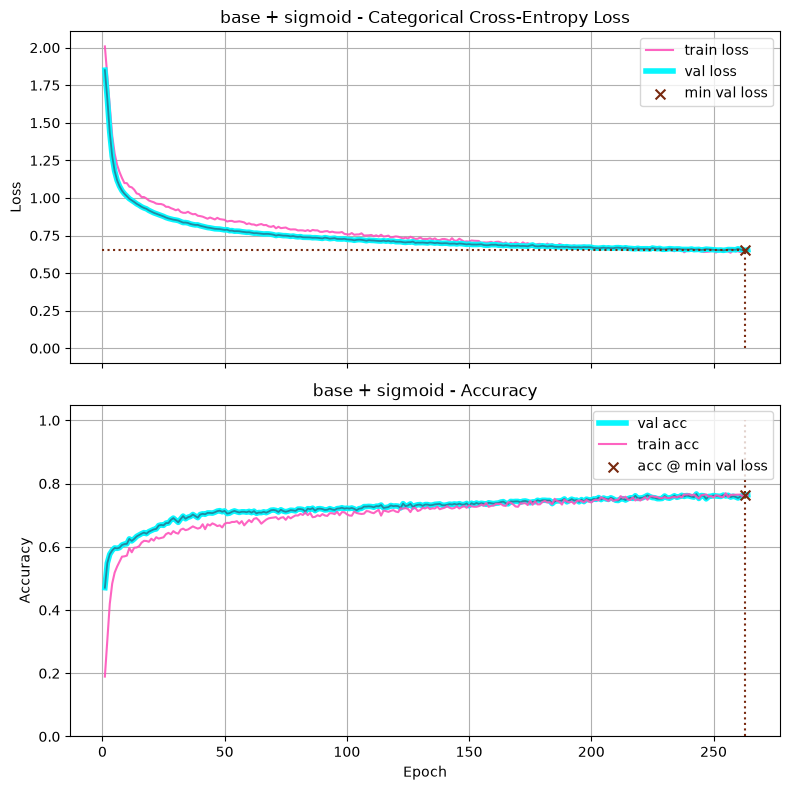

Final Training Loss:            0.6414
Final Training Accuracy:        0.7629
Final Validation Loss:          0.6541
Final Validation Accuracy:      0.7643
Minimum Validation Loss:        0.6510 (Epoch 263)
Validation Accuracy @ Min Loss: 0.7636

Test Loss: 0.6712
Test Accuracy: 0.7500

Validation-Test Gap (accuracy): 0.013571

Execution Time: 00:01:46

base + tanh



I0000 00:00:1789567280.721438    2818 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_140984__.17
I0000 00:00:1789567282.103912    2819 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_140984__.17


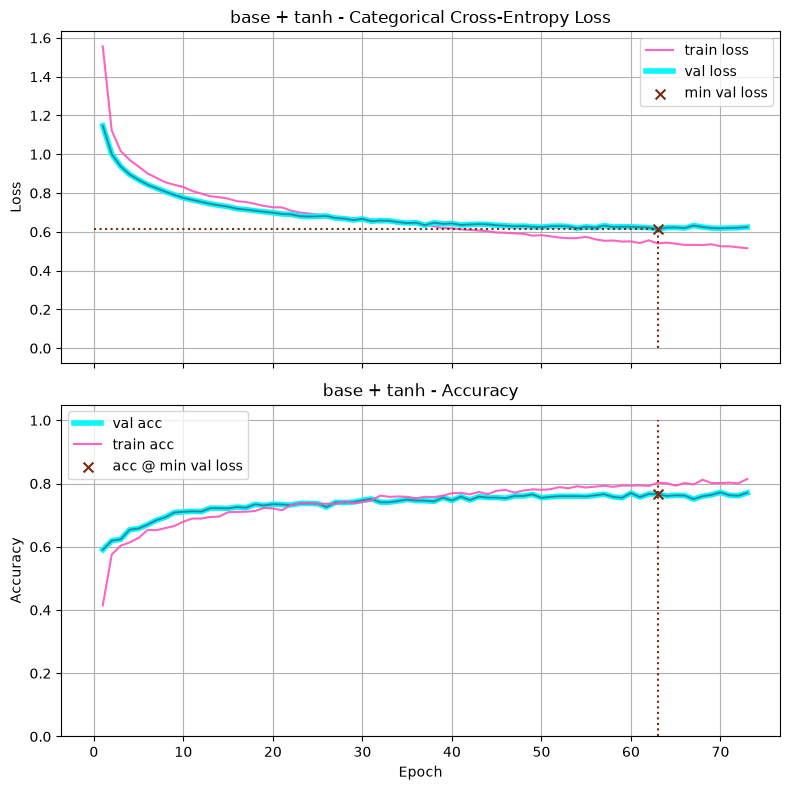

Final Training Loss:            0.5155
Final Training Accuracy:        0.8145
Final Validation Loss:          0.6243
Final Validation Accuracy:      0.7707
Minimum Validation Loss:        0.6137 (Epoch 63)
Validation Accuracy @ Min Loss: 0.7671

Test Loss: 0.6345
Test Accuracy: 0.7536

Validation-Test Gap (accuracy): 0.013571

Execution Time: 00:00:33


In [12]:
p1_mivl = []
p1_epml = []
p1_vacml = []
p1_title = []


for actl in ['relu', 'sigmoid', 'tanh']: 
    base_layer = [
        ##width--act--l2--DOrate##
        (64,    actl,  0.0,     0.0), 
        (32,    actl,  0.001,   0.0)
        ]
    
    model_baseline = build_model(n_inputs, base_layer, n_classes)
    model_baseline_hx = train_and_test(
        model_baseline, 
        epochs        = 500,                   
        lr_schedule   = 0.001,                 
        optimizer     = "Adam",
        title         = f"base + {actl}",
        batch_size    = 64,                     
        use_early_stopping = True,
        patience      = 10,                                       
        min_delta     = 0.0001,                 
        callbacks     = [],                    
        verbose       = 0,
        return_history = True
    )

    min_val_loss = min(model_baseline_hx.history['val_loss'])
    epoch_loc_min_loss = model_baseline_hx.history['val_loss'].index(min_val_loss)
    val_acc_min_loss = (model_baseline_hx.history['val_accuracy'][epoch_loc_min_loss])


    p1_mivl.append(min_val_loss)
    p1_epml.append(epoch_loc_min_loss+1)
    p1_vacml.append(val_acc_min_loss)
    p1_title.append(actl)




In [13]:
print_results()

base + relu                             	0.7764
base + tanh                             	0.7671
base + sigmoid                          	0.7636


In [14]:
# max(results.items(), key = lambda x: x[1][0])[1][0]

In [15]:
p1_tab = pd.DataFrame({
    "type": "activation",
    "variable": p1_title,
    "min_loss_validation": p1_mivl,
    "epoch": p1_epml,
    "accuracy_validation": p1_vacml
})

p1_tab.sort_values('accuracy_validation', ascending=False).round(3)

,type,variable,min_loss_validation,epoch,accuracy_validation
0,activation,relu,0.601,78,0.776
1,activation,sigmoid,0.651,263,0.764
2,activation,tanh,0.614,63,0.767


---

# p2


relu & LR + 0.001



I0000 00:00:1789567314.277657    2819 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_171072__.17
I0000 00:00:1789567315.614221    2818 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_171072__.17


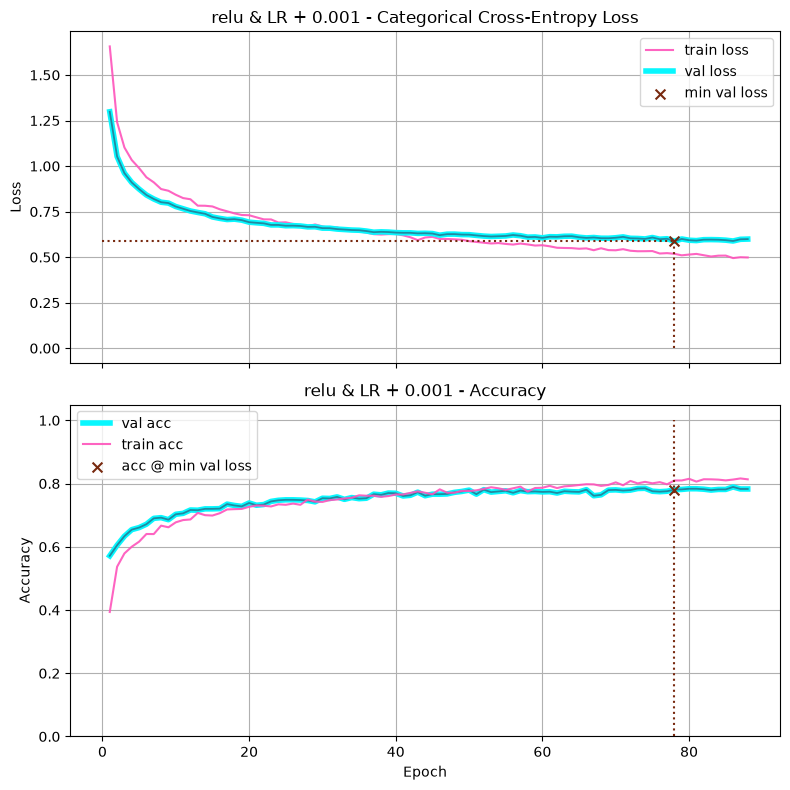

Final Training Loss:            0.4982
Final Training Accuracy:        0.8133
Final Validation Loss:          0.5991
Final Validation Accuracy:      0.7829
Minimum Validation Loss:        0.5874 (Epoch 78)
Validation Accuracy @ Min Loss: 0.7807

Test Loss: 0.6131
Test Accuracy: 0.7607

Validation-Test Gap (accuracy): 0.020000

Execution Time: 00:00:38

relu & LR + 0.0005



I0000 00:00:1789567352.617365    2820 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_207001__.17
I0000 00:00:1789567353.973935    2818 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_207001__.17


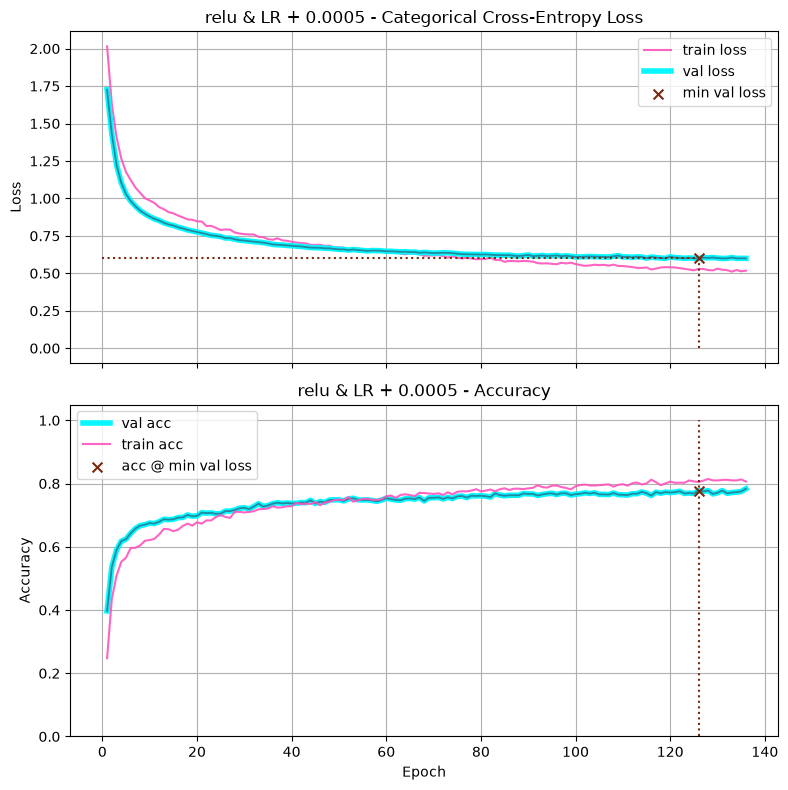

Final Training Loss:            0.5178
Final Training Accuracy:        0.8064
Final Validation Loss:          0.5996
Final Validation Accuracy:      0.7836
Minimum Validation Loss:        0.5990 (Epoch 126)
Validation Accuracy @ Min Loss: 0.7779

Test Loss: 0.6229
Test Accuracy: 0.7571

Validation-Test Gap (accuracy): 0.020714

Execution Time: 00:00:56

relu & LR + 0.0001



I0000 00:00:1789567409.444794    2819 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_261494__.17
I0000 00:00:1789567410.774789    2819 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_261494__.17


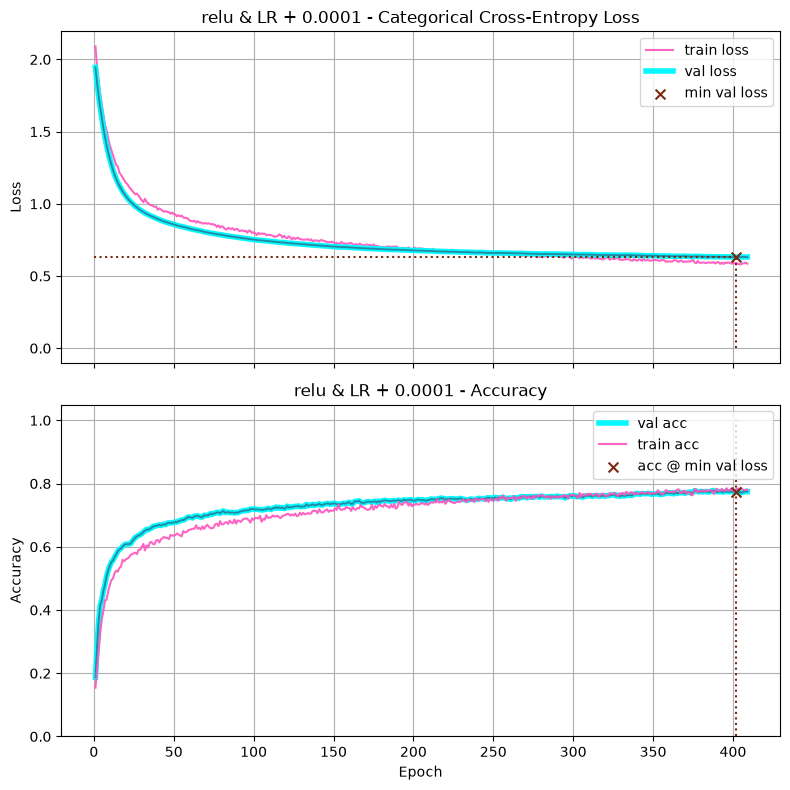

Final Training Loss:            0.5855
Final Training Accuracy:        0.7805
Final Validation Loss:          0.6315
Final Validation Accuracy:      0.7750
Minimum Validation Loss:        0.6309 (Epoch 402)
Validation Accuracy @ Min Loss: 0.7736

Test Loss: 0.6425
Test Accuracy: 0.7493

Validation-Test Gap (accuracy): 0.025714

Execution Time: 00:02:41

relu & LR + 5e-05



I0000 00:00:1789567571.333184    2820 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_421830__.17
I0000 00:00:1789567572.681368    2819 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_421830__.17


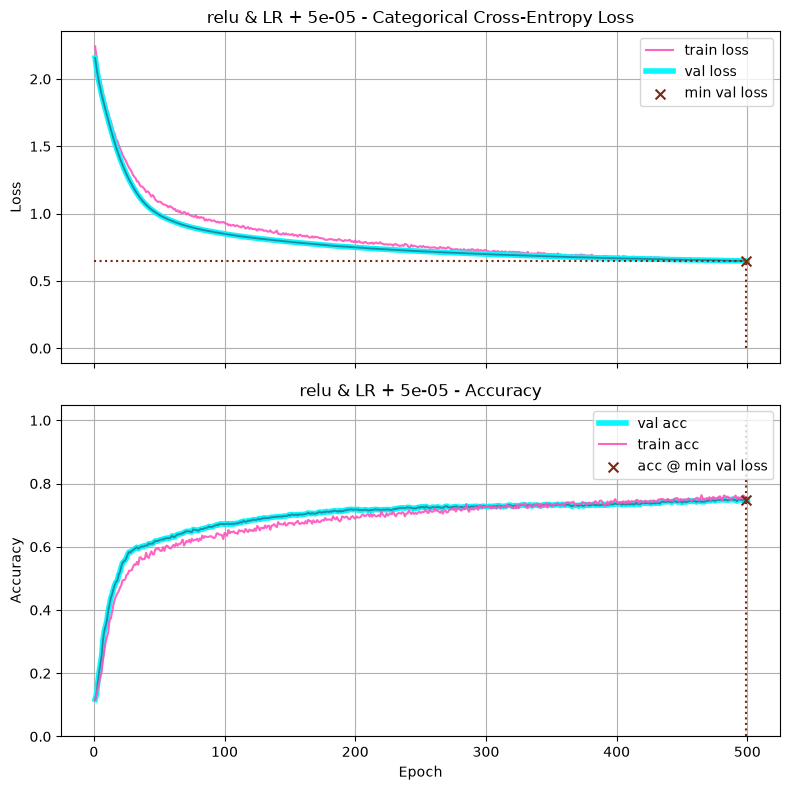

Final Training Loss:            0.6457
Final Training Accuracy:        0.7548
Final Validation Loss:          0.6483
Final Validation Accuracy:      0.7486
Minimum Validation Loss:        0.6481 (Epoch 499)
Validation Accuracy @ Min Loss: 0.7479

Test Loss: 0.6737
Test Accuracy: 0.7436

Validation-Test Gap (accuracy): 0.004286

Execution Time: 00:03:17

relu & LR + 1e-05



I0000 00:00:1789567768.462079    2817 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_618419__.17
I0000 00:00:1789567769.859753    2821 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_618419__.17


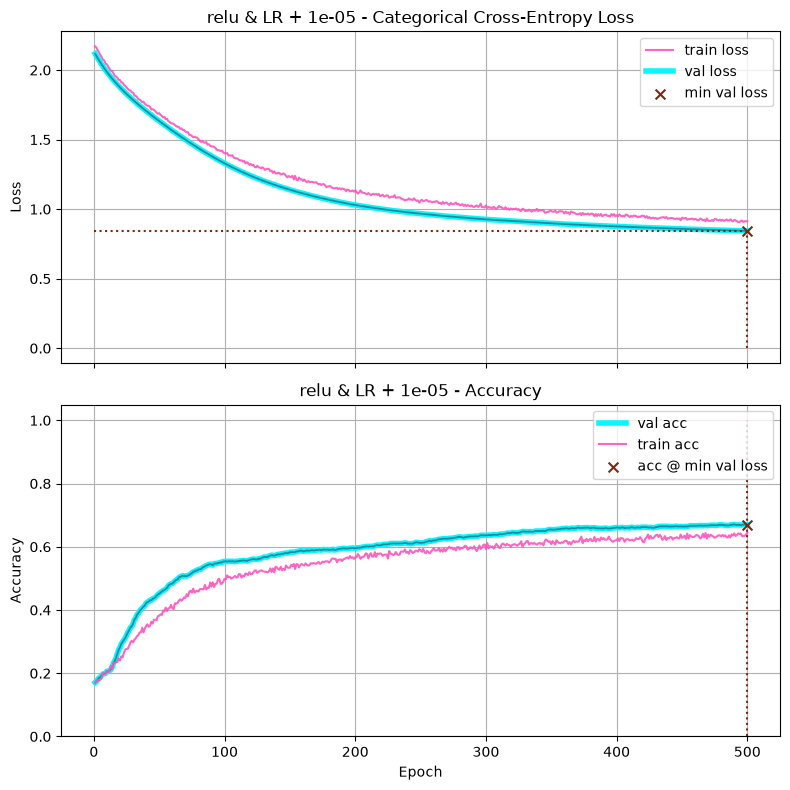

Final Training Loss:            0.9124
Final Training Accuracy:        0.6452
Final Validation Loss:          0.8435
Final Validation Accuracy:      0.6693
Minimum Validation Loss:        0.8435 (Epoch 500)
Validation Accuracy @ Min Loss: 0.6693

Test Loss: 0.8582
Test Accuracy: 0.6764

Validation-Test Gap (accuracy): 0.007143

Execution Time: 00:03:18


In [16]:
p2_mivl = []
p2_epml = []
p2_vacml = []
p2_title = []


for lr in [1e-3, 5e-4, 1e-4, 5e-5, 1e-5]: 
    base_layer = [
        ##width--act--l2--DOrate##
        (64,    'relu',  0.0,       0.0), 
        (32,    'relu',  0.001,     0.0)
        ]
    
    model_baseline = build_model(n_inputs, base_layer, n_classes)
    model_baseline_hx = train_and_test(
        model_baseline, 
        epochs        = 500,                   
        lr_schedule   = lr,                 
        optimizer     = "Adam",
        title         = f"relu & LR = {lr}",
        batch_size    = 64,                     
        use_early_stopping = True,
        patience      = 10,                                       
        min_delta     = 0.0001,                 
        callbacks     = [],                    
        verbose       = 0,
        return_history = True
    )

    min_val_loss = min(model_baseline_hx.history['val_loss'])
    epoch_loc_min_loss = model_baseline_hx.history['val_loss'].index(min_val_loss)
    val_acc_min_loss = (model_baseline_hx.history['val_accuracy'][epoch_loc_min_loss])


    p2_mivl.append(min_val_loss)
    p2_epml.append(epoch_loc_min_loss+1)
    p2_vacml.append(val_acc_min_loss)
    p2_title.append(lr)




In [17]:
p2_tab = pd.DataFrame({
    "type": "learning rate",
    "variable": p2_title,
    "min_loss_validation": p2_mivl,
    "epoch": p2_epml,
    "accuracy_validation": p2_vacml
})

(p2_tab
 .sort_values('accuracy_validation')
 .round({'min_loss_validation':3, 'accuracy_validation':3})
)

,type,variable,min_loss_validation,epoch,accuracy_validation
0,learning rate,0.001,0.587,78,0.781
1,learning rate,0.000,0.599,126,0.778
2,learning rate,0.000,0.631,402,0.774
3,learning rate,0.000,0.648,499,0.748
4,learning rate,0.000,0.844,500,0.669


In [21]:
(p2_tab
 .sort_values('accuracy_validation', ascending=False)
 .round({'min_loss_validation':3, 'accuracy_validation':3})
)

,type,variable,min_loss_validation,epoch,accuracy_validation
4,learning rate,0.00001,0.844,500,0.669
3,learning rate,0.00005,0.648,499,0.748
2,learning rate,0.00010,0.631,402,0.774
1,learning rate,0.00050,0.599,126,0.778
0,learning rate,0.00100,0.587,78,0.781


---

# p3


relu & LR=0.001 & DO= 0.0,0.0



I0000 00:00:1789570846.810035    2819 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_815799__.16
I0000 00:00:1789570847.879480    2819 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_815799__.16


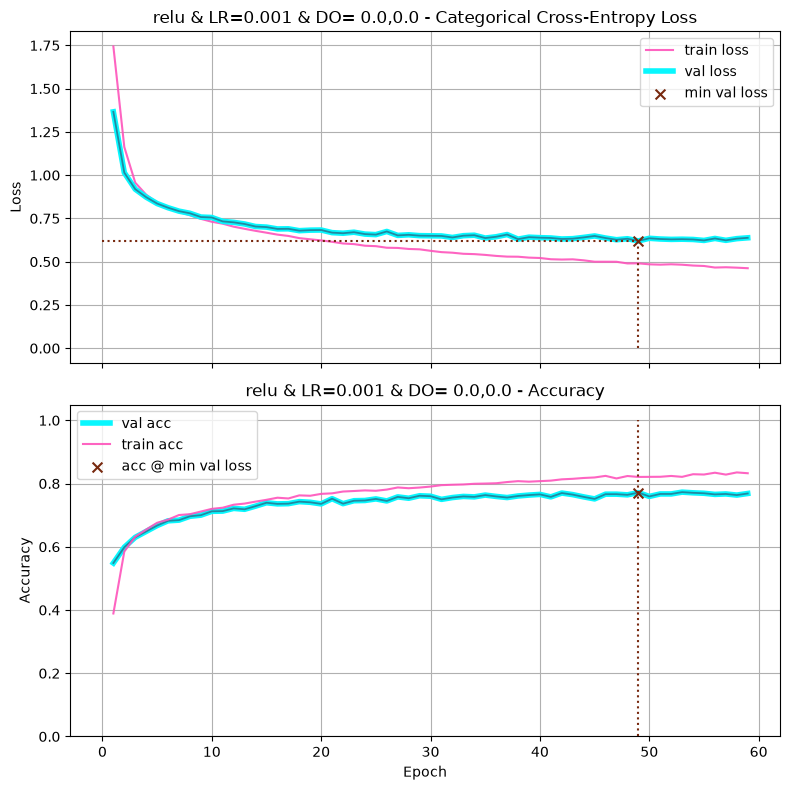

Final Training Loss:            0.4623
Final Training Accuracy:        0.8326
Final Validation Loss:          0.6380
Final Validation Accuracy:      0.7686
Minimum Validation Loss:        0.6199 (Epoch 49)
Validation Accuracy @ Min Loss: 0.7714

Test Loss: 0.6294
Test Accuracy: 0.7657

Validation-Test Gap (accuracy): 0.005714

Execution Time: 00:00:27

relu & LR=0.001 & DO= 0.0,0.2



I0000 00:00:1789570874.418761    2819 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_840483__.17
I0000 00:00:1789570875.788851    2819 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_840483__.17


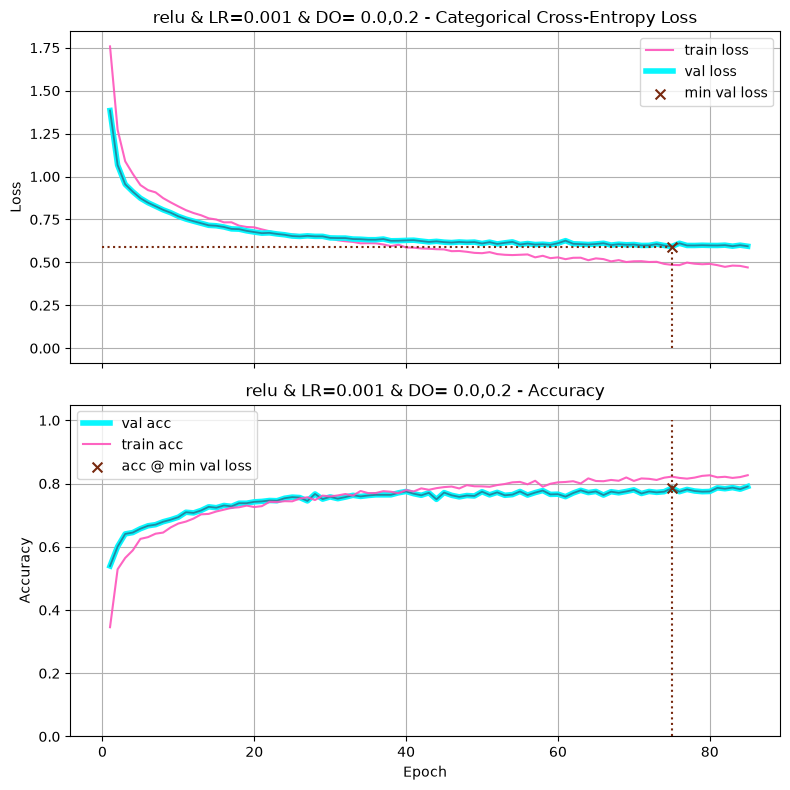

Final Training Loss:            0.4705
Final Training Accuracy:        0.8264
Final Validation Loss:          0.5939
Final Validation Accuracy:      0.7907
Minimum Validation Loss:        0.5923 (Epoch 75)
Validation Accuracy @ Min Loss: 0.7857

Test Loss: 0.6239
Test Accuracy: 0.7714

Validation-Test Gap (accuracy): 0.014286

Execution Time: 00:00:38

relu & LR=0.001 & DO= 0.0,0.5



I0000 00:00:1789570912.565500    2819 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_875191__.17
I0000 00:00:1789570913.904158    2821 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_875191__.17


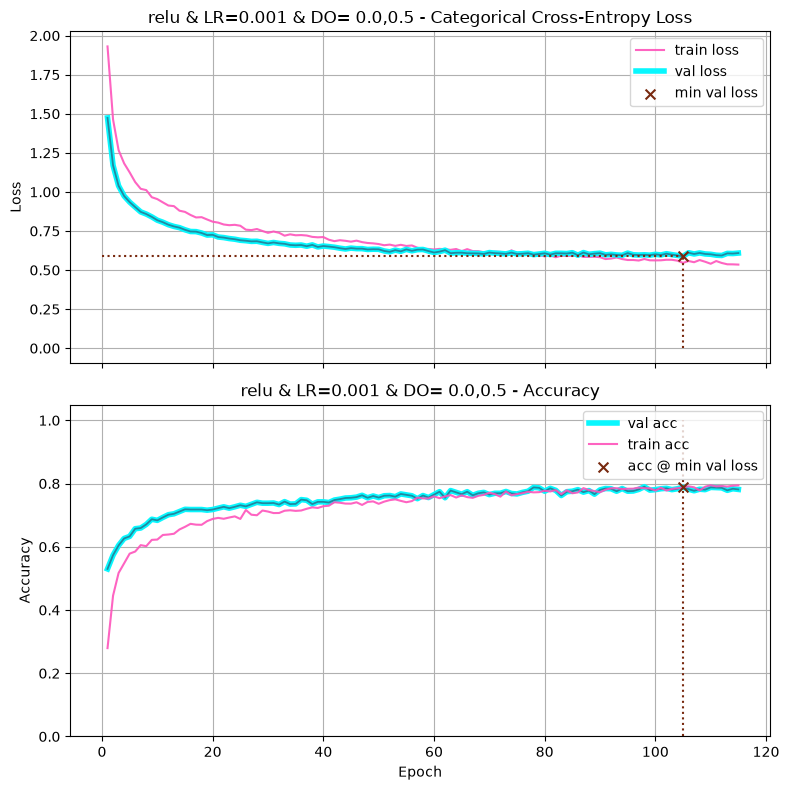

Final Training Loss:            0.5350
Final Training Accuracy:        0.7943
Final Validation Loss:          0.6087
Final Validation Accuracy:      0.7814
Minimum Validation Loss:        0.5883 (Epoch 105)
Validation Accuracy @ Min Loss: 0.7886

Test Loss: 0.6416
Test Accuracy: 0.7729

Validation-Test Gap (accuracy): 0.015714

Execution Time: 00:00:50

relu & LR=0.001 & DO= 0.2,0.0



I0000 00:00:1789570962.579069    2819 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_921341__.17
I0000 00:00:1789570964.020425    2819 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_921341__.17


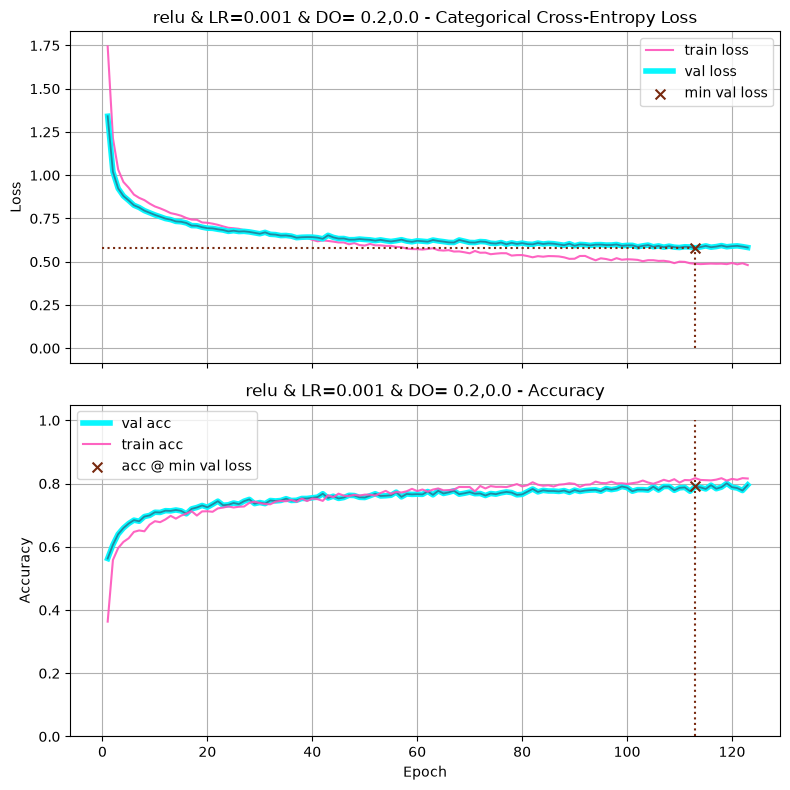

Final Training Loss:            0.4806
Final Training Accuracy:        0.8160
Final Validation Loss:          0.5821
Final Validation Accuracy:      0.7957
Minimum Validation Loss:        0.5799 (Epoch 113)
Validation Accuracy @ Min Loss: 0.7907

Test Loss: 0.5955
Test Accuracy: 0.7850

Validation-Test Gap (accuracy): 0.005714

Execution Time: 00:00:52

relu & LR=0.001 & DO= 0.2,0.2



I0000 00:00:1789571015.031167    2820 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_970669__.18
I0000 00:00:1789571016.752878    2818 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_970669__.18


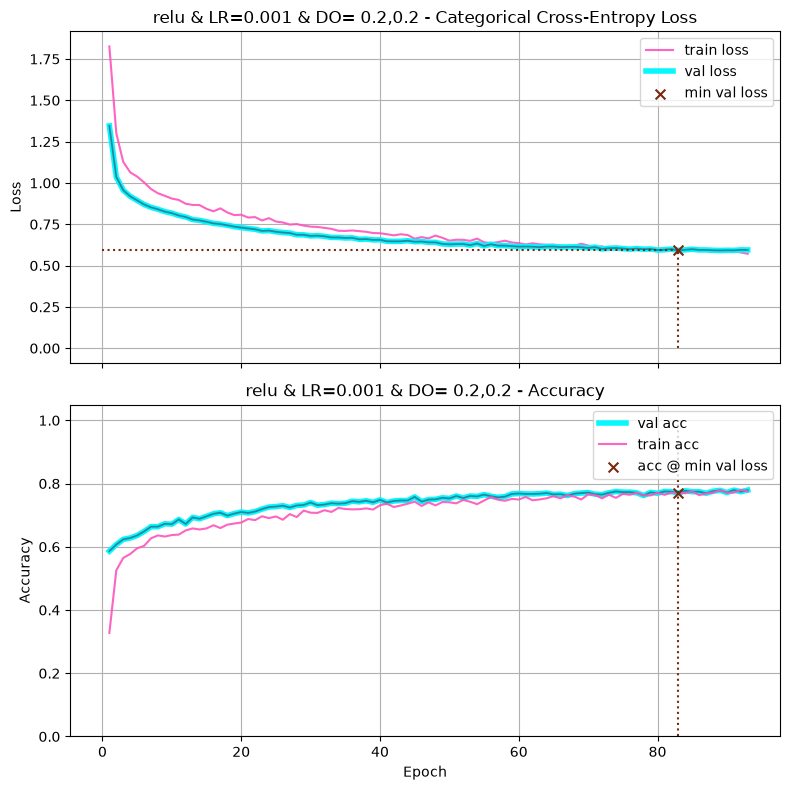

Final Training Loss:            0.5715
Final Training Accuracy:        0.7755
Final Validation Loss:          0.5945
Final Validation Accuracy:      0.7793
Minimum Validation Loss:        0.5916 (Epoch 83)
Validation Accuracy @ Min Loss: 0.7700

Test Loss: 0.6233
Test Accuracy: 0.7557

Validation-Test Gap (accuracy): 0.014286

Execution Time: 00:00:42

relu & LR=0.001 & DO= 0.2,0.5



I0000 00:00:1789571057.163767    2821 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1008617__.18
I0000 00:00:1789571058.803163    2821 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1008617__.18


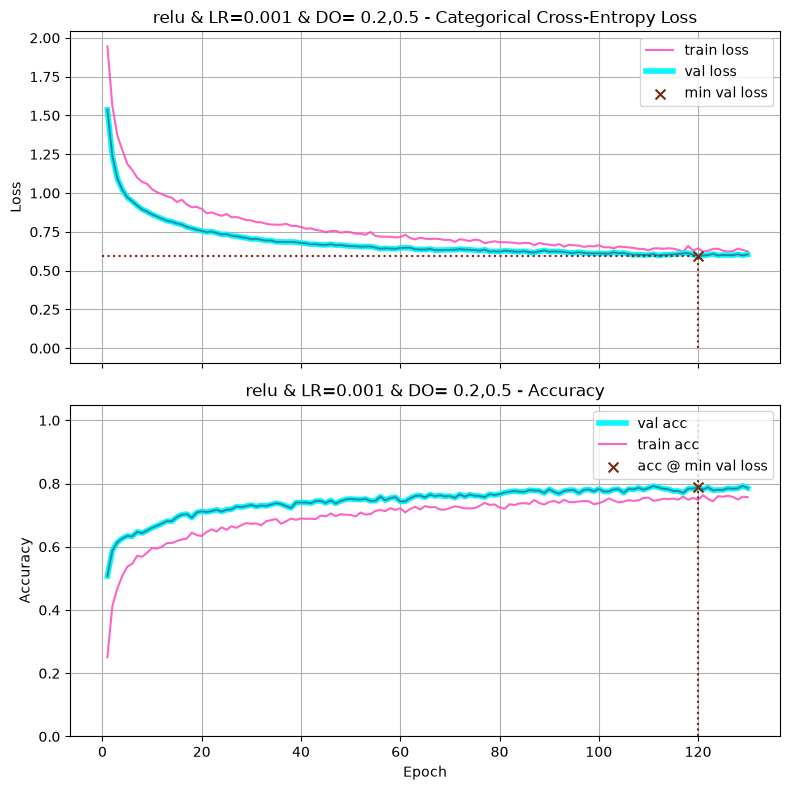

Final Training Loss:            0.6248
Final Training Accuracy:        0.7569
Final Validation Loss:          0.6040
Final Validation Accuracy:      0.7857
Minimum Validation Loss:        0.5956 (Epoch 120)
Validation Accuracy @ Min Loss: 0.7879

Test Loss: 0.6543
Test Accuracy: 0.7629

Validation-Test Gap (accuracy): 0.025000

Execution Time: 00:00:57

relu & LR=0.001 & DO= 0.5,0.0



I0000 00:00:1789571114.472117    2820 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1060682__.17
I0000 00:00:1789571115.804041    2818 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1060682__.17


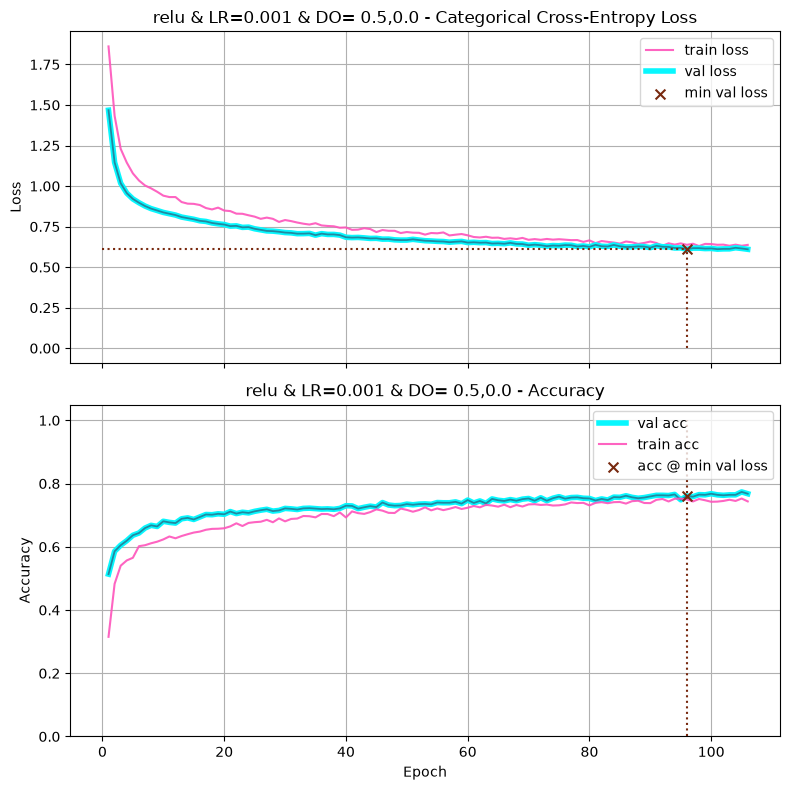

Final Training Loss:            0.6372
Final Training Accuracy:        0.7436
Final Validation Loss:          0.6101
Final Validation Accuracy:      0.7679
Minimum Validation Loss:        0.6100 (Epoch 96)
Validation Accuracy @ Min Loss: 0.7607

Test Loss: 0.6340
Test Accuracy: 0.7564

Validation-Test Gap (accuracy): 0.004286

Execution Time: 00:00:45

relu & LR=0.001 & DO= 0.5,0.2



I0000 00:00:1789571160.506834    2819 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1103591__.18
I0000 00:00:1789571162.157715    2819 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1103591__.18


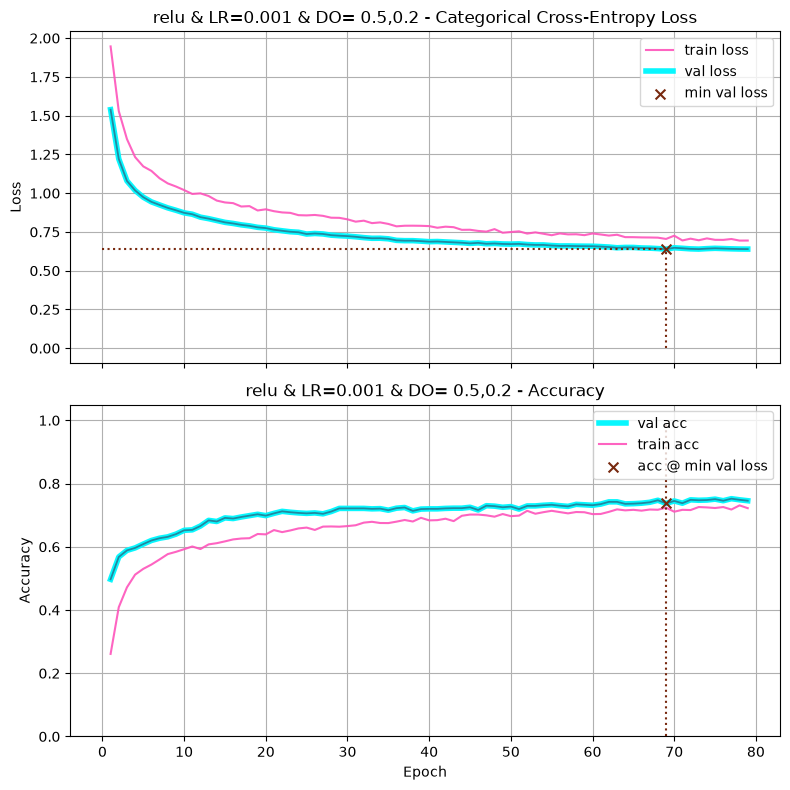

Final Training Loss:            0.6945
Final Training Accuracy:        0.7221
Final Validation Loss:          0.6394
Final Validation Accuracy:      0.7457
Minimum Validation Loss:        0.6387 (Epoch 69)
Validation Accuracy @ Min Loss: 0.7371

Test Loss: 0.6718
Test Accuracy: 0.7343

Validation-Test Gap (accuracy): 0.002857

Execution Time: 00:00:38

relu & LR=0.001 & DO= 0.5,0.5



I0000 00:00:1789571198.500586    2819 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1136269__.18
I0000 00:00:1789571200.111028    2819 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1136269__.18


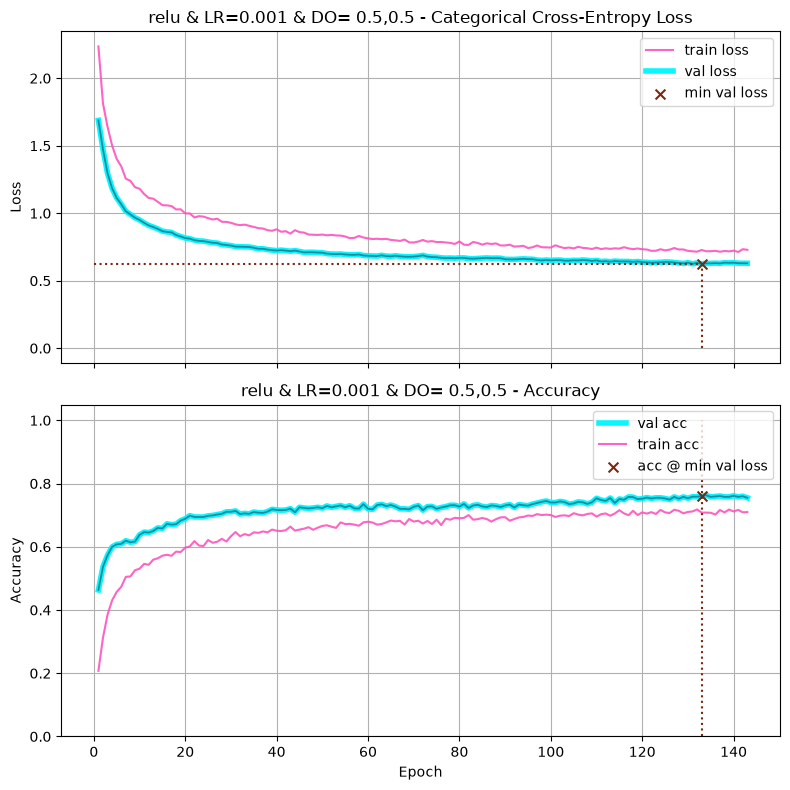

Final Training Loss:            0.7287
Final Training Accuracy:        0.7098
Final Validation Loss:          0.6291
Final Validation Accuracy:      0.7550
Minimum Validation Loss:        0.6246 (Epoch 133)
Validation Accuracy @ Min Loss: 0.7600

Test Loss: 0.6612
Test Accuracy: 0.7457

Validation-Test Gap (accuracy): 0.014286

Execution Time: 00:01:02


,type,variable,min_loss_validation,epoch,accuracy_validation
3,dropout rate,"layer1=0.2, layer2=0.0",0.580,113,0.791
2,dropout rate,"layer1=0.0, layer2=0.5",0.588,105,0.789
5,dropout rate,"layer1=0.2, layer2=0.5",0.596,120,0.788
1,dropout rate,"layer1=0.0, layer2=0.2",0.592,75,0.786
0,dropout rate,"layer1=0.0, layer2=0.0",0.620,49,0.771
4,dropout rate,"layer1=0.2, layer2=0.2",0.592,83,0.770
6,dropout rate,"layer1=0.5, layer2=0.0",0.610,96,0.761
8,dropout rate,"layer1=0.5, layer2=0.5",0.625,133,0.760
7,dropout rate,"layer1=0.5, layer2=0.2",0.639,69,0.737


In [22]:
p3_mivl = []
p3_epml = []
p3_vacml = []
p3_title = []
p3_proc_dur = []

P1_best = 'relu'
p2_best = 1e-3


from itertools import product
# dropout_combo = [0.0 , 0.2 , 0.3 , 0.4 , 0.5]
dropout_combo = [0.0 , 0.2 , 0.5]


for do1, do2 in product(dropout_combo, repeat = 2): 
    base_layer = [
        ##width--act--l2--DOrate##
        (64,    P1_best,  0.0,       do1), 
        (32,    P1_best,  0.001,     do2)
        ]
    proc_start = time.time()
    model_baseline = build_model(n_inputs, base_layer, n_classes)
    model_baseline_hx = train_and_test(
        model_baseline, 
        epochs        = 500,                   
        lr_schedule   = p2_best,                 
        optimizer     = "Adam",
        title         = f"{P1_best} & LR={p2_best} & DO= {do1},{do2}",
        batch_size    = 64,                     
        use_early_stopping = True,
        patience      = 10,                                       
        min_delta     = 0.0001,                 
        callbacks     = [],                    
        verbose       = 0,
        return_history = True
    )


    proc_end = time.time()


    min_val_loss = min(model_baseline_hx.history['val_loss'])
    epoch_loc_min_loss = model_baseline_hx.history['val_loss'].index(min_val_loss)
    val_acc_min_loss = (model_baseline_hx.history['val_accuracy'][epoch_loc_min_loss])


    p3_mivl.append(min_val_loss)
    p3_epml.append(epoch_loc_min_loss+1)
    p3_vacml.append(val_acc_min_loss)
    p3_title.append(f"({do1},{do2})")
    p3_proc_dur.append(f"{proc_end - proc_start}")

    #---------------------------------------------------

p3_tab = pd.DataFrame({
    "type": "dropout rate",
    "variable": p3_title,
    "min_loss_validation": p3_mivl,
    "epoch": p3_epml,
    "accuracy_validation": p3_vacml
})

(p3_tab
 .sort_values('accuracy_validation', ascending=False)
 .round({'min_loss_validation':3, 'accuracy_validation':3})
)




----

# p4


relu & LR=0.001 & DO= 0,0 & L2=(0.0001,0.0001)



I0000 00:00:1789574045.524277    2819 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1193319__.16
I0000 00:00:1789574046.503397    2819 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1193319__.16


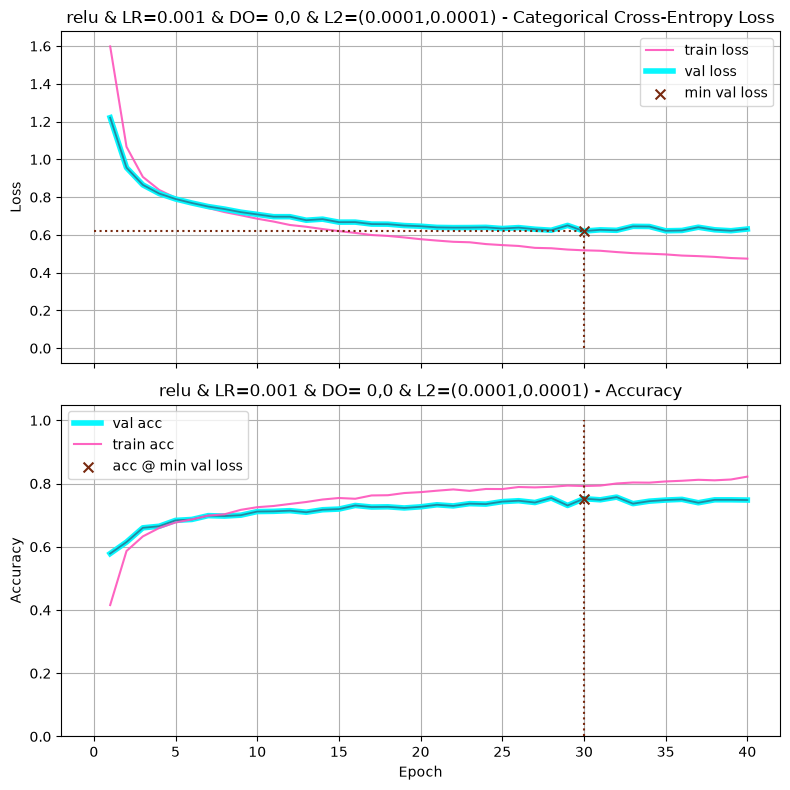

Final Training Loss:            0.4744
Final Training Accuracy:        0.8219
Final Validation Loss:          0.6312
Final Validation Accuracy:      0.7479
Minimum Validation Loss:        0.6201 (Epoch 30)
Validation Accuracy @ Min Loss: 0.7521

Test Loss: 0.6309
Test Accuracy: 0.7521

Validation-Test Gap (accuracy): 0.000000

Execution Time: 00:00:20

relu & LR=0.001 & DO= 0,0 & L2=(0.0001,0.001)



I0000 00:00:1789574065.892352    2818 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1210632__.16
I0000 00:00:1789574066.823050    2818 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1210632__.16


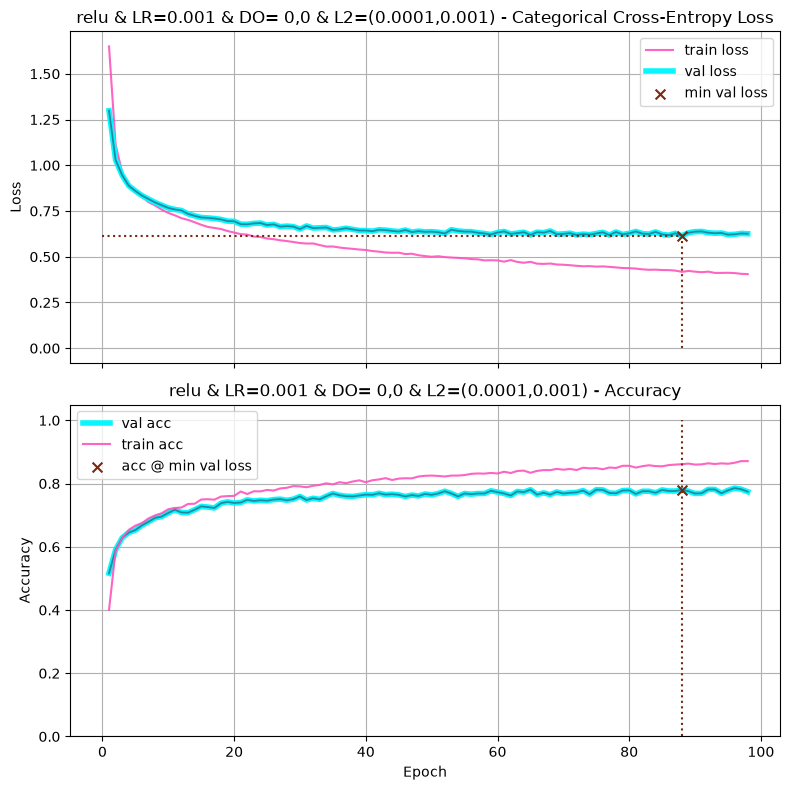

Final Training Loss:            0.4050
Final Training Accuracy:        0.8710
Final Validation Loss:          0.6259
Final Validation Accuracy:      0.7743
Minimum Validation Loss:        0.6142 (Epoch 88)
Validation Accuracy @ Min Loss: 0.7800

Test Loss: 0.6517
Test Accuracy: 0.7736

Validation-Test Gap (accuracy): 0.006429

Execution Time: 00:00:41

relu & LR=0.001 & DO= 0,0 & L2=(0.0001,0.01)



I0000 00:00:1789574107.942943    2818 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1250119__.16
I0000 00:00:1789574108.913516    2821 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1250119__.16


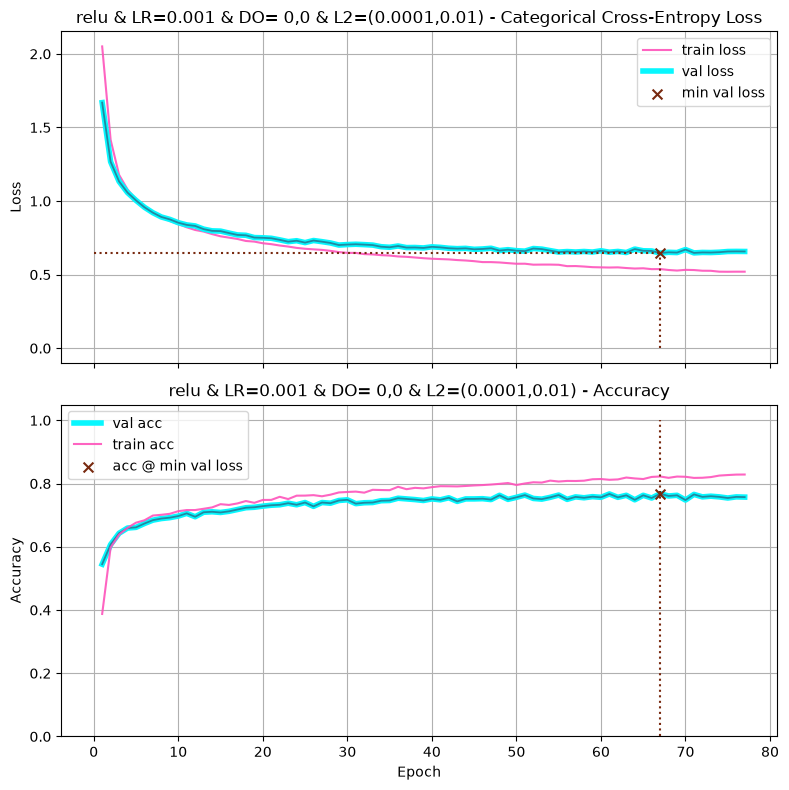

Final Training Loss:            0.5200
Final Training Accuracy:        0.8286
Final Validation Loss:          0.6573
Final Validation Accuracy:      0.7571
Minimum Validation Loss:        0.6462 (Epoch 67)
Validation Accuracy @ Min Loss: 0.7679

Test Loss: 0.6583
Test Accuracy: 0.7564

Validation-Test Gap (accuracy): 0.011429

Execution Time: 00:00:35

relu & LR=0.001 & DO= 0,0 & L2=(0.001,0.0001)



I0000 00:00:1789574142.987421    2819 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1281671__.16
I0000 00:00:1789574143.885571    2819 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1281671__.16


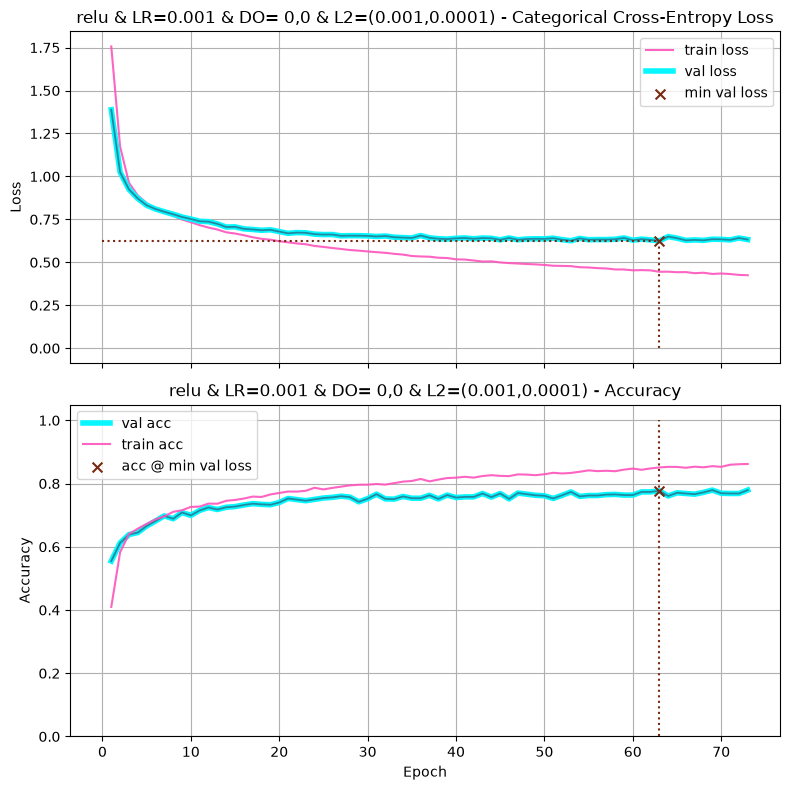

Final Training Loss:            0.4249
Final Training Accuracy:        0.8619
Final Validation Loss:          0.6326
Final Validation Accuracy:      0.7793
Minimum Validation Loss:        0.6248 (Epoch 63)
Validation Accuracy @ Min Loss: 0.7771

Test Loss: 0.6520
Test Accuracy: 0.7621

Validation-Test Gap (accuracy): 0.015000

Execution Time: 00:00:33

relu & LR=0.001 & DO= 0,0 & L2=(0.001,0.001)



I0000 00:00:1789574176.040569    2820 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1311599__.16
I0000 00:00:1789574176.970744    2820 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1311599__.16


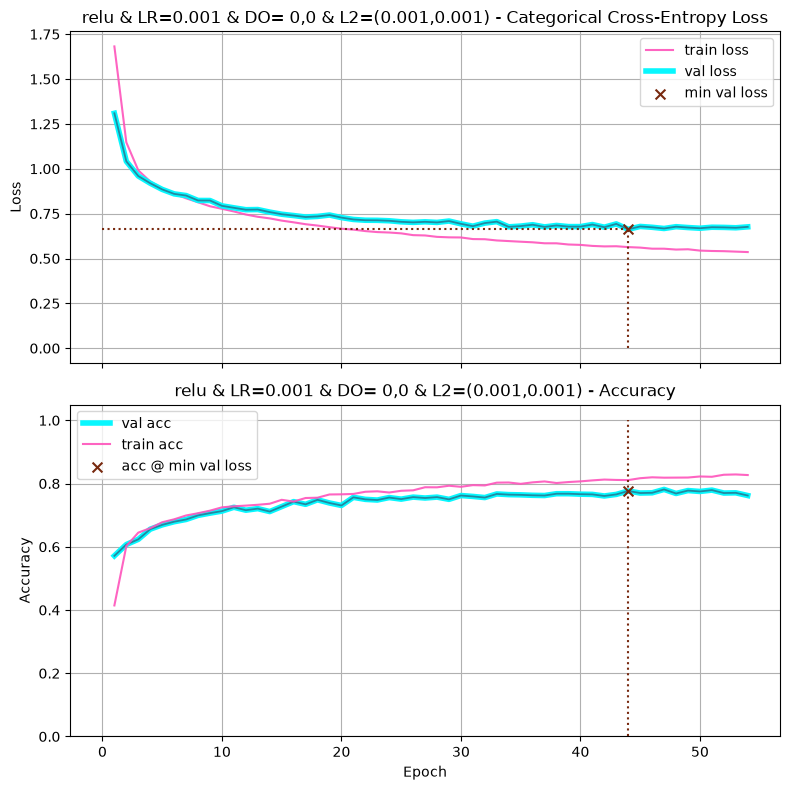

Final Training Loss:            0.5359
Final Training Accuracy:        0.8269
Final Validation Loss:          0.6763
Final Validation Accuracy:      0.7621
Minimum Validation Loss:        0.6626 (Epoch 44)
Validation Accuracy @ Min Loss: 0.7764

Test Loss: 0.6952
Test Accuracy: 0.7607

Validation-Test Gap (accuracy): 0.015714

Execution Time: 00:00:25

relu & LR=0.001 & DO= 0,0 & L2=(0.001,0.01)



I0000 00:00:1789574201.866245    2817 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1334302__.16
I0000 00:00:1789574202.780693    2817 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1334302__.16


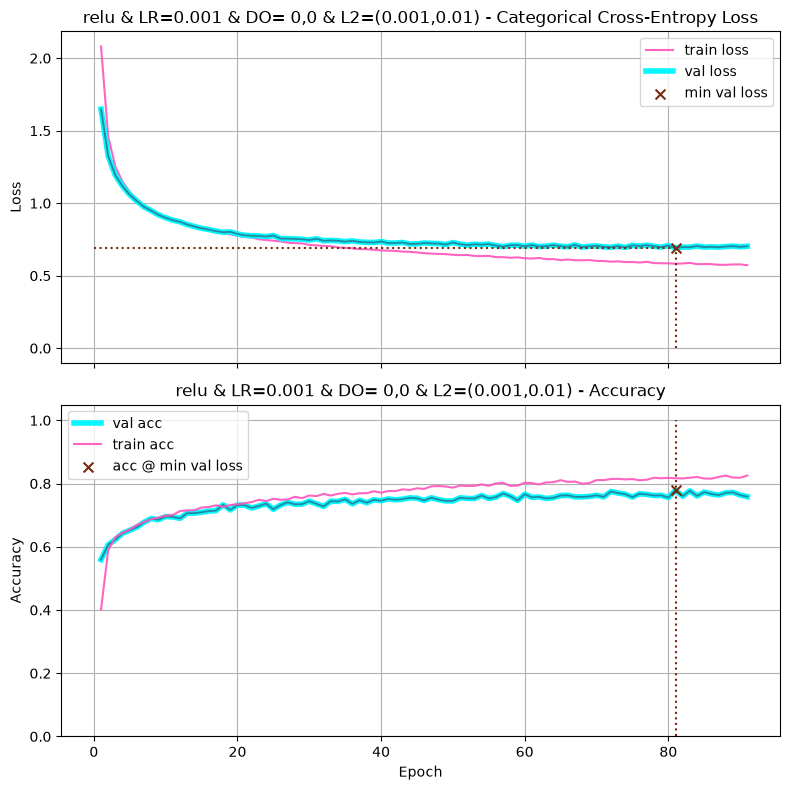

Final Training Loss:            0.5725
Final Training Accuracy:        0.8255
Final Validation Loss:          0.7032
Final Validation Accuracy:      0.7586
Minimum Validation Loss:        0.6916 (Epoch 81)
Validation Accuracy @ Min Loss: 0.7793

Test Loss: 0.7003
Test Accuracy: 0.7593

Validation-Test Gap (accuracy): 0.020000

Execution Time: 00:00:39

relu & LR=0.001 & DO= 0,0 & L2=(0.01,0.0001)



I0000 00:00:1789574241.451236    2821 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1371196__.16
I0000 00:00:1789574242.438193    2821 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1371196__.16


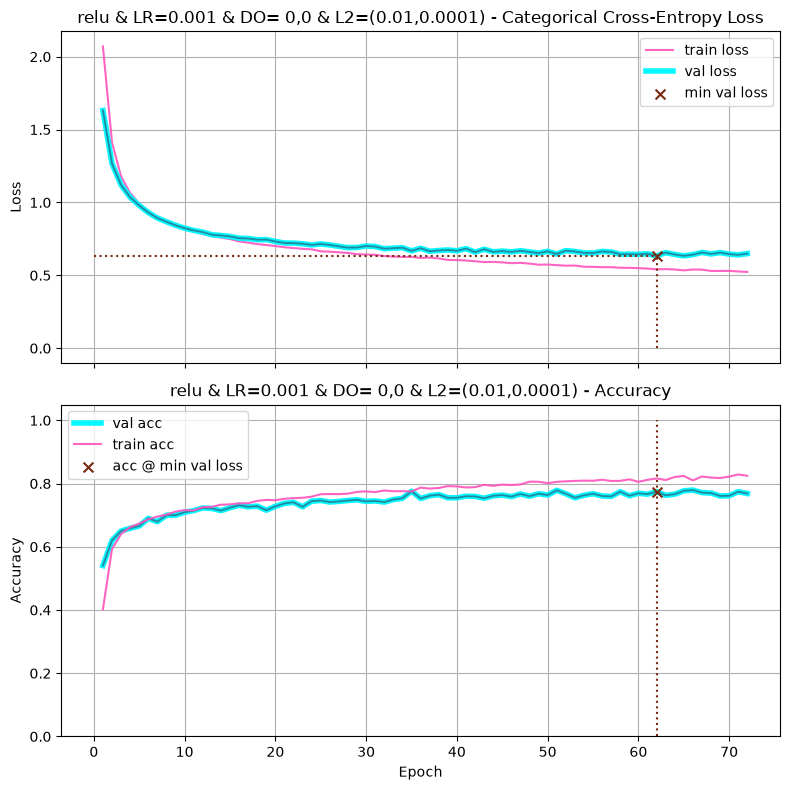

Final Training Loss:            0.5233
Final Training Accuracy:        0.8245
Final Validation Loss:          0.6493
Final Validation Accuracy:      0.7686
Minimum Validation Loss:        0.6327 (Epoch 62)
Validation Accuracy @ Min Loss: 0.7743

Test Loss: 0.6678
Test Accuracy: 0.7686

Validation-Test Gap (accuracy): 0.005714

Execution Time: 00:00:32

relu & LR=0.001 & DO= 0,0 & L2=(0.01,0.001)



I0000 00:00:1789574273.905267    2817 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1400769__.16
I0000 00:00:1789574274.887715    2820 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1400769__.16


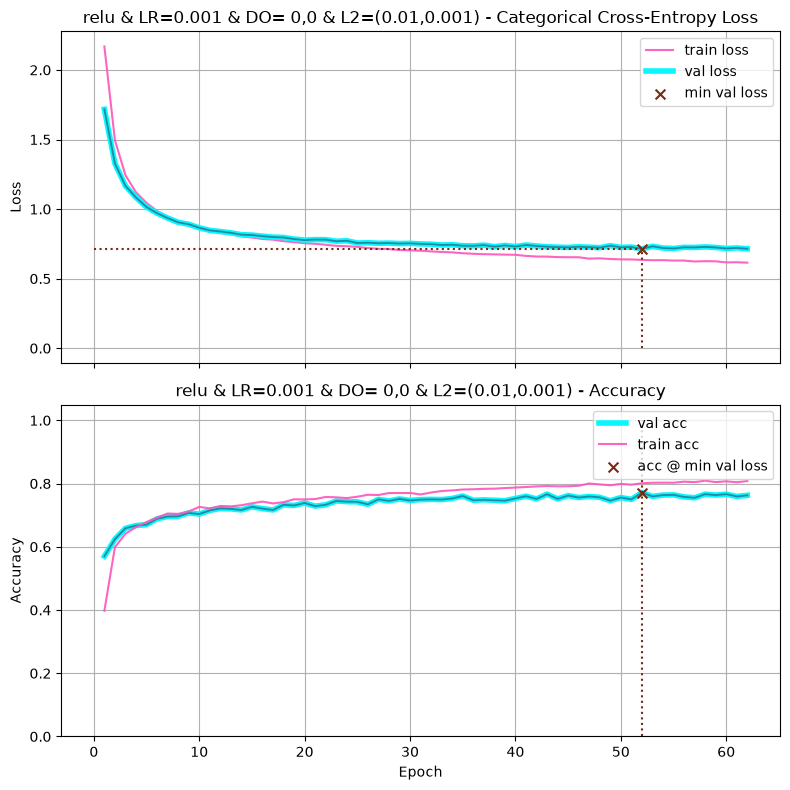

Final Training Loss:            0.6149
Final Training Accuracy:        0.8079
Final Validation Loss:          0.7146
Final Validation Accuracy:      0.7629
Minimum Validation Loss:        0.7136 (Epoch 52)
Validation Accuracy @ Min Loss: 0.7714

Test Loss: 0.7217
Test Accuracy: 0.7621

Validation-Test Gap (accuracy): 0.009286

Execution Time: 00:00:28

relu & LR=0.001 & DO= 0,0 & L2=(0.01,0.01)



I0000 00:00:1789574302.349975    2820 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1426564__.16
I0000 00:00:1789574303.302628    2817 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1426564__.16


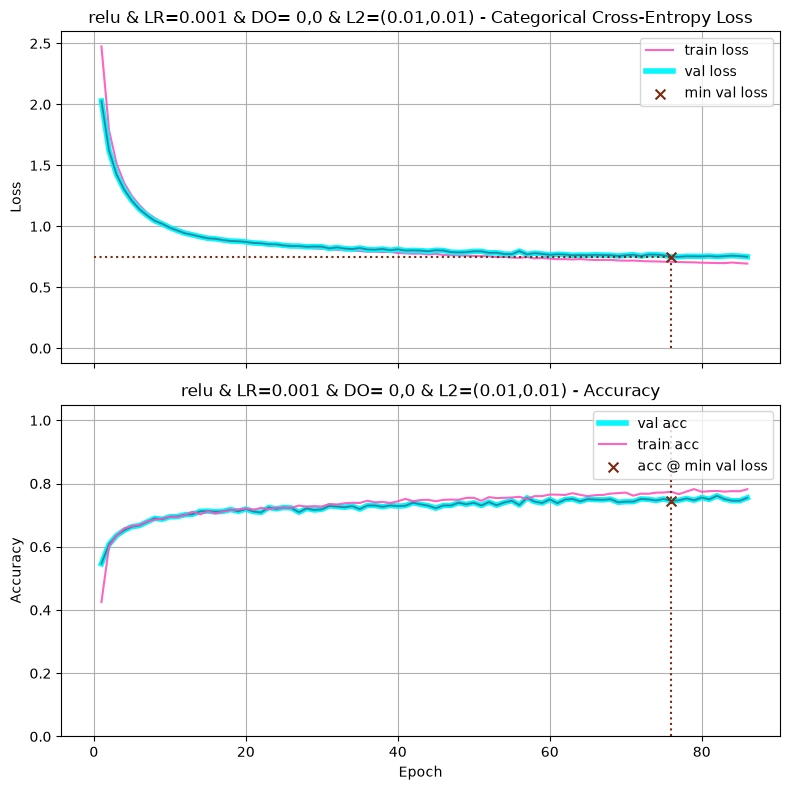

Final Training Loss:            0.6944
Final Training Accuracy:        0.7821
Final Validation Loss:          0.7500
Final Validation Accuracy:      0.7550
Minimum Validation Loss:        0.7494 (Epoch 76)
Validation Accuracy @ Min Loss: 0.7450

Test Loss: 0.7571
Test Accuracy: 0.7436

Validation-Test Gap (accuracy): 0.001429

Execution Time: 00:00:37


In [27]:
p4_mivl = []
p4_epml = []
p4_vacml = []
p4_title = []
p4_proc_dur = []

P1_best = 'relu'
p2_best = 1e-3

l2_reg = [1e-4, 1e-3, 1e-2]

for l2_1, l2_2 in product(l2_reg, repeat=2): 
    base_layer = [
        ##width--act--l2--DOrate##
        (64,    P1_best,  l2_1,       0), 
        (32,    P1_best,  l2_2,     0)
        ]
    proc_start = time.time()
    model_baseline = build_model(n_inputs, base_layer, n_classes)
    model_baseline_hx = train_and_test(
        model_baseline, 
        epochs        = 500,                   
        lr_schedule   = p2_best,                 
        optimizer     = "Adam",
        title         = f"{P1_best} & LR={p2_best} & DO= 0,0 & L2=({l2_1},{l2_2})",
        batch_size    = 64,                     
        use_early_stopping = True,
        patience      = 10,                                       
        min_delta     = 0.0001,                 
        callbacks     = [],                    
        verbose       = 0,
        return_history = True
    )


    proc_end = time.time()


    min_val_loss = min(model_baseline_hx.history['val_loss'])
    epoch_loc_min_loss = model_baseline_hx.history['val_loss'].index(min_val_loss)
    val_acc_min_loss = (model_baseline_hx.history['val_accuracy'][epoch_loc_min_loss])


    p4_mivl.append(min_val_loss)
    p4_epml.append(epoch_loc_min_loss+1)
    p4_vacml.append(val_acc_min_loss)
    p4_title.append(f"({l2_1},{l2_2})")
    p4_proc_dur.append(f"{format_hms(proc_end - proc_start)}")

    #---------------------------------------------------

p4_tab = pd.DataFrame({
    "type": "L2 regularization rate",
    "variable": p4_title,
    "min_loss_validation": p4_mivl,
    "epoch": p4_epml,
    "accuracy_validation": p4_vacml,
    "process_time": p4_proc_dur
})

# (p4_tab
#  .sort_values('accuracy_validation', ascending=False)
#  .round({'min_loss_validation':3, 'accuracy_validation':3})
# )




In [37]:
p4_tab = pd.DataFrame({
    "type": "L2 regularization rate",
    "variable": p4_title,
    "min_loss_validation": p4_mivl,
    "epoch": p4_epml,
    "accuracy_validation": p4_vacml,
    "process_time": p4_proc_dur
})
(p4_tab
 .sort_values('accuracy_validation', ascending=False)
 .round({'min_loss_validation':3, 'accuracy_validation':3, 'process_time': 3})
)

,type,variable,min_loss_validation,epoch,accuracy_validation,process_time
1,L2 regularization rate,"(0.0001,0.001)",0.614,88,0.780,41.67714023590088
5,L2 regularization rate,"(0.001,0.01)",0.692,81,0.779,39.559112548828125
3,L2 regularization rate,"(0.001,0.0001)",0.625,63,0.777,33.05088973045349
4,L2 regularization rate,"(0.001,0.001)",0.663,44,0.776,25.8506498336792
6,L2 regularization rate,"(0.01,0.0001)",0.633,62,0.774,32.4853777885437
7,L2 regularization rate,"(0.01,0.001)",0.714,52,0.771,28.45176672935486
2,L2 regularization rate,"(0.0001,0.01)",0.646,67,0.768,35.40084791183472
0,L2 regularization rate,"(0.0001,0.0001)",0.620,30,0.752,20.522802352905273
8,L2 regularization rate,"(0.01,0.01)",0.749,76,0.745,37.51760411262512


In [36]:
max(results.items(), key= lambda x:x[1][0])

('relu & LR=0.001 & DO= 0.2,0.0', (0.7907142639160156, 113))

---

# p5


relu & LR=0.001 & DO= 0.2,0.0 & L2=(0.0001,0.0001)



I0000 00:00:1789580267.238831    2818 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1461673__.17
I0000 00:00:1789580268.581709    2821 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1461673__.17


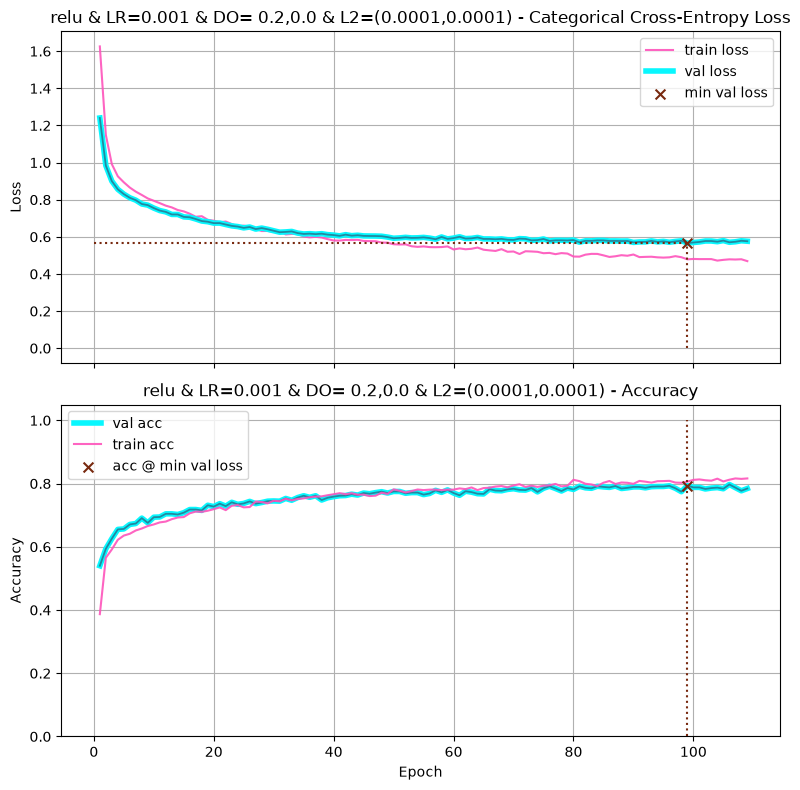

Final Training Loss:            0.4691
Final Training Accuracy:        0.8162
Final Validation Loss:          0.5762
Final Validation Accuracy:      0.7843
Minimum Validation Loss:        0.5662 (Epoch 99)
Validation Accuracy @ Min Loss: 0.7936

Test Loss: 0.6007
Test Accuracy: 0.7636

Validation-Test Gap (accuracy): 0.030000

Execution Time: 00:00:48

relu & LR=0.001 & DO= 0.0,0.1 & L2=(0.0001,0.0001)



I0000 00:00:1789580316.467248    2820 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1505537__.17
I0000 00:00:1789580317.791134    2819 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1505537__.17


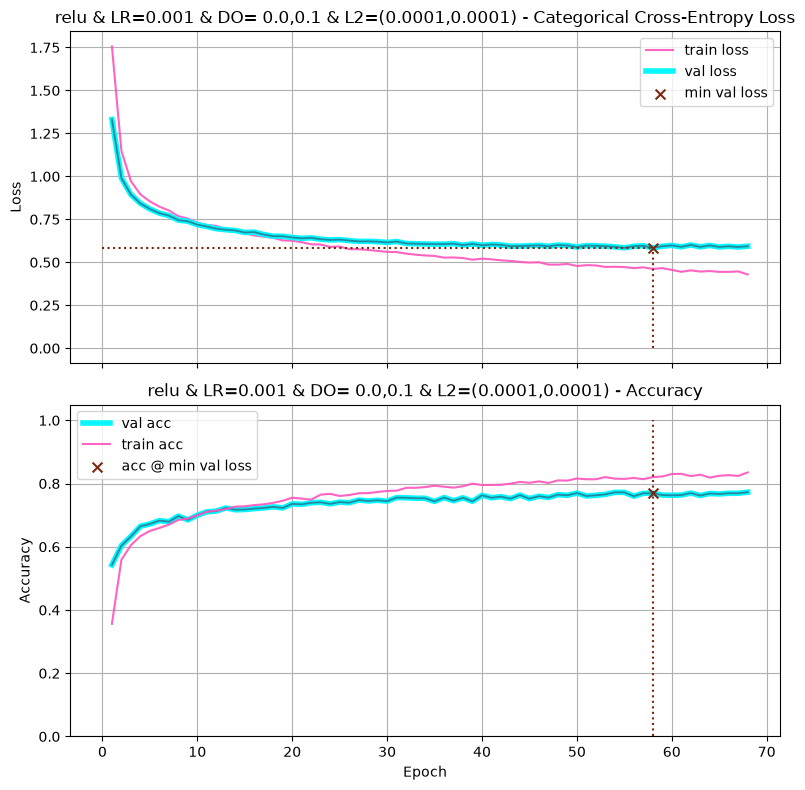

Final Training Loss:            0.4290
Final Training Accuracy:        0.8352
Final Validation Loss:          0.5937
Final Validation Accuracy:      0.7729
Minimum Validation Loss:        0.5836 (Epoch 58)
Validation Accuracy @ Min Loss: 0.7693

Test Loss: 0.5979
Test Accuracy: 0.7679

Validation-Test Gap (accuracy): 0.001429

Execution Time: 00:00:31

relu & LR=0.001 & DO= 0.1,0.0 & L2=(0.0001,0.0001)



I0000 00:00:1789580347.087320    2817 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1533718__.17
I0000 00:00:1789580348.490839    2820 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1533718__.17


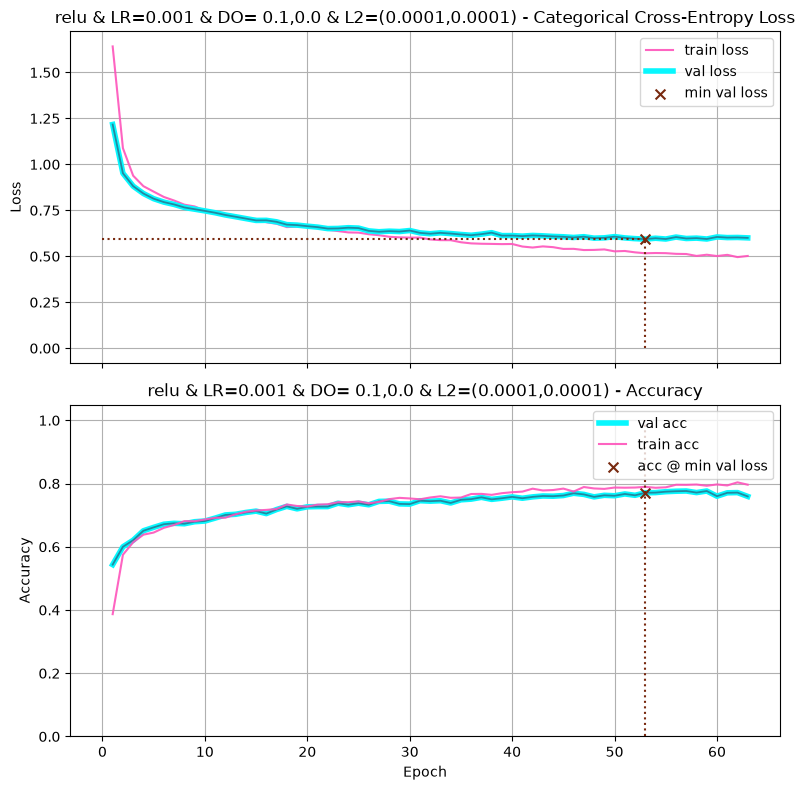

Final Training Loss:            0.5018
Final Training Accuracy:        0.7964
Final Validation Loss:          0.6002
Final Validation Accuracy:      0.7593
Minimum Validation Loss:        0.5933 (Epoch 53)
Validation Accuracy @ Min Loss: 0.7707

Test Loss: 0.5968
Test Accuracy: 0.7543

Validation-Test Gap (accuracy): 0.016429

Execution Time: 00:00:29

relu & LR=0.001 & DO= 0.2,0.0 & L2=(0.001,0.001)



I0000 00:00:1789580376.195582    2819 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1559980__.17
I0000 00:00:1789580377.562086    2821 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1559980__.17


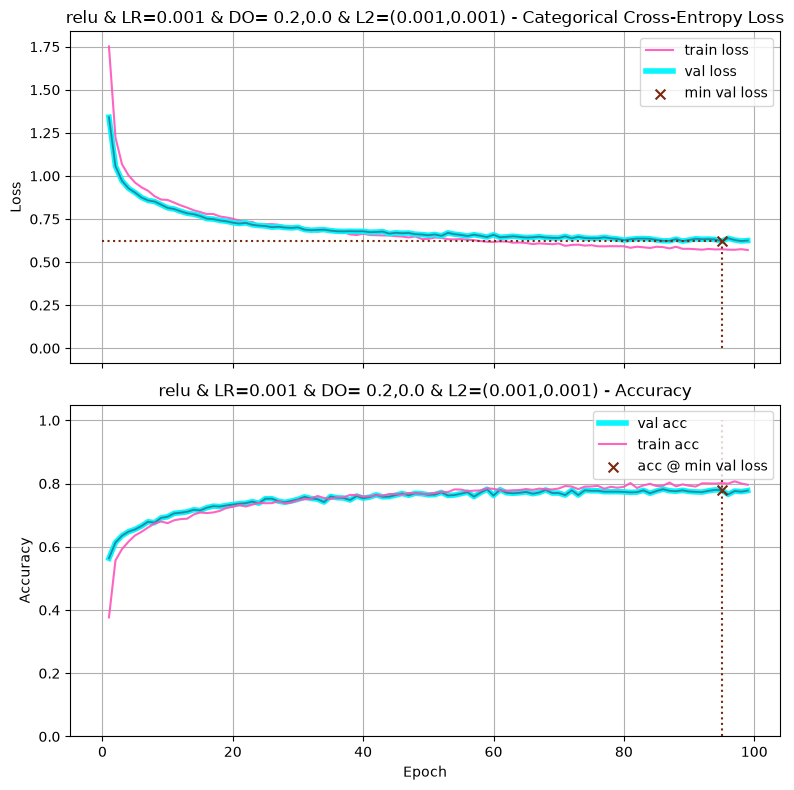

Final Training Loss:            0.5700
Final Training Accuracy:        0.7962
Final Validation Loss:          0.6251
Final Validation Accuracy:      0.7779
Minimum Validation Loss:        0.6216 (Epoch 95)
Validation Accuracy @ Min Loss: 0.7793

Test Loss: 0.6545
Test Accuracy: 0.7657

Validation-Test Gap (accuracy): 0.012857

Execution Time: 00:00:44

relu & LR=0.001 & DO= 0.0,0.1 & L2=(0.001,0.001)



I0000 00:00:1789580420.346838    2819 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1600078__.17
I0000 00:00:1789580421.751428    2819 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1600078__.17


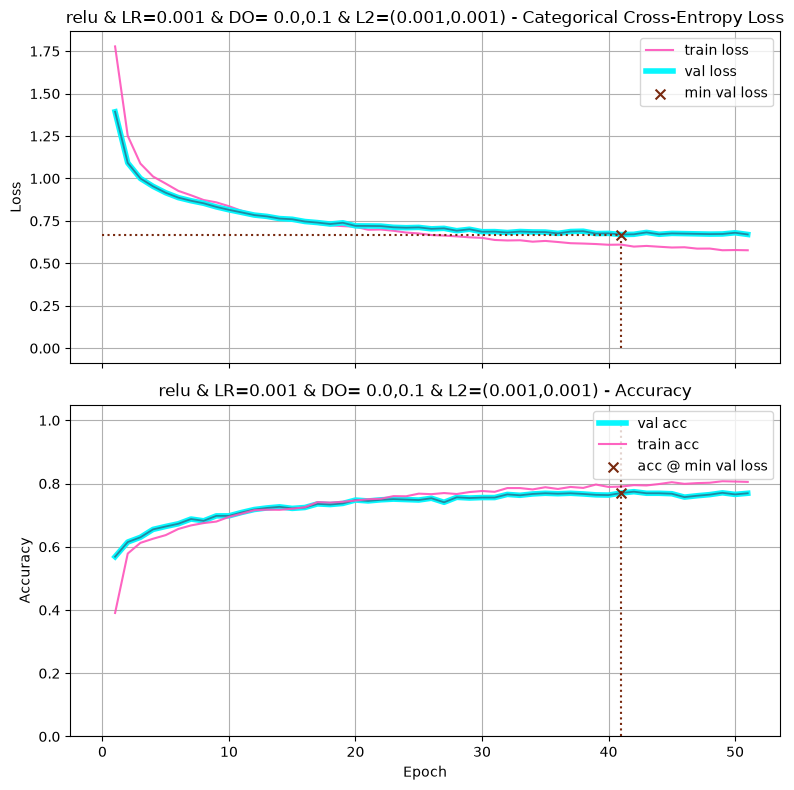

Final Training Loss:            0.5771
Final Training Accuracy:        0.8052
Final Validation Loss:          0.6702
Final Validation Accuracy:      0.7693
Minimum Validation Loss:        0.6696 (Epoch 41)
Validation Accuracy @ Min Loss: 0.7700

Test Loss: 0.6983
Test Accuracy: 0.7543

Validation-Test Gap (accuracy): 0.015714

Execution Time: 00:00:25

relu & LR=0.001 & DO= 0.1,0.0 & L2=(0.001,0.001)



I0000 00:00:1789580445.961181    2817 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1621732__.17
I0000 00:00:1789580447.370687    2817 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1621732__.17


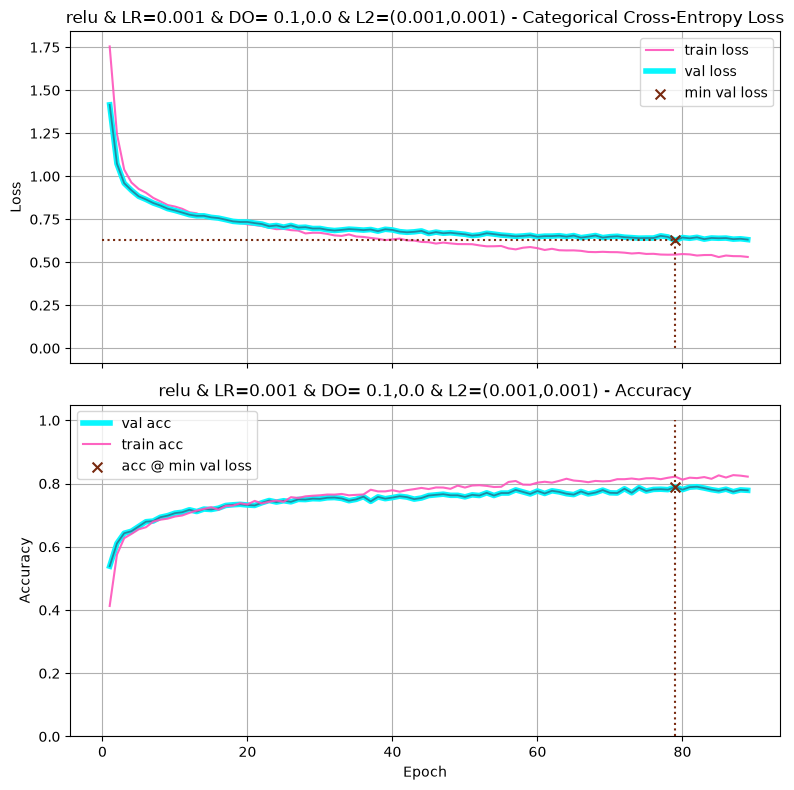

Final Training Loss:            0.5307
Final Training Accuracy:        0.8219
Final Validation Loss:          0.6314
Final Validation Accuracy:      0.7786
Minimum Validation Loss:        0.6269 (Epoch 79)
Validation Accuracy @ Min Loss: 0.7893

Test Loss: 0.6579
Test Accuracy: 0.7786

Validation-Test Gap (accuracy): 0.010714

Execution Time: 00:00:40

relu & LR=0.001 & DO= 0.2,0.0 & L2=(0.01,0.01)



I0000 00:00:1789580486.477881    2821 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1657872__.17
I0000 00:00:1789580487.885637    2821 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1657872__.17


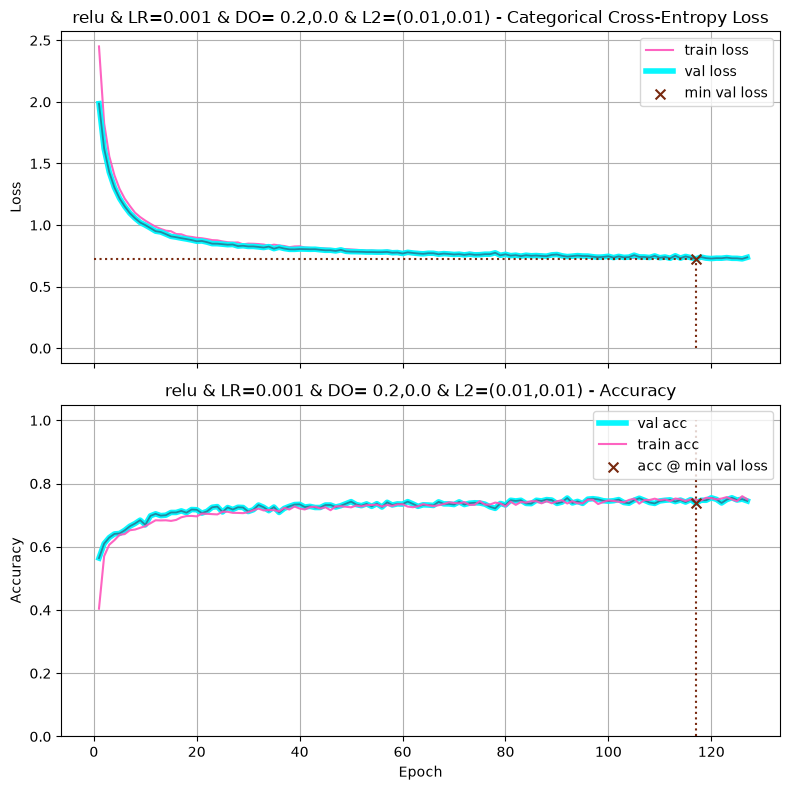

Final Training Loss:            0.7283
Final Training Accuracy:        0.7500
Final Validation Loss:          0.7379
Final Validation Accuracy:      0.7450
Minimum Validation Loss:        0.7251 (Epoch 117)
Validation Accuracy @ Min Loss: 0.7379

Test Loss: 0.7430
Test Accuracy: 0.7393

Validation-Test Gap (accuracy): 0.001429

Execution Time: 00:00:55

relu & LR=0.001 & DO= 0.0,0.1 & L2=(0.01,0.01)



I0000 00:00:1789580541.859380    2819 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1708654__.17
I0000 00:00:1789580543.203135    2821 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1708654__.17


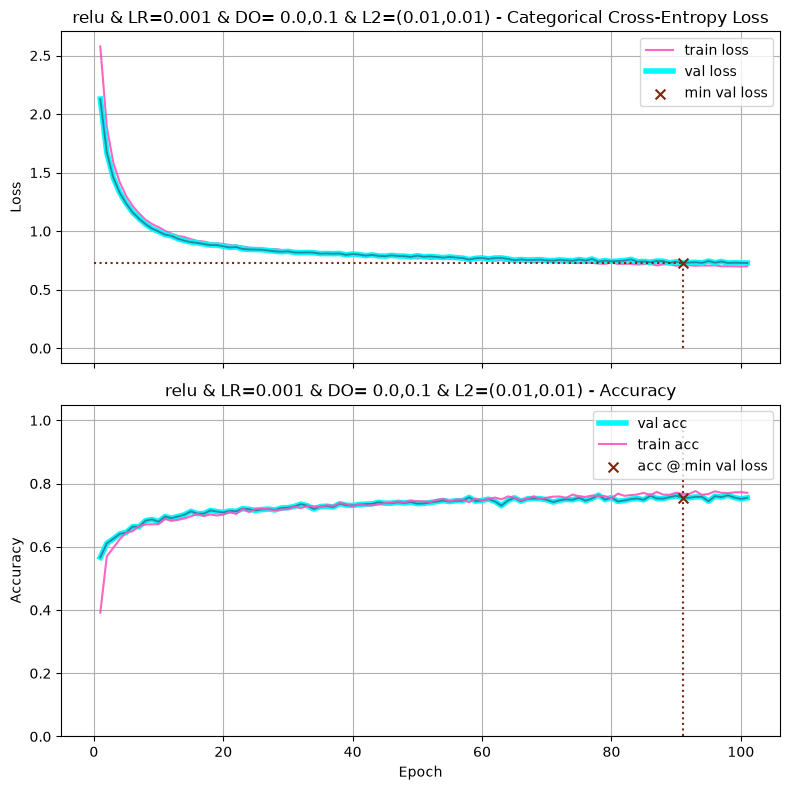

Final Training Loss:            0.7004
Final Training Accuracy:        0.7707
Final Validation Loss:          0.7277
Final Validation Accuracy:      0.7550
Minimum Validation Loss:        0.7269 (Epoch 91)
Validation Accuracy @ Min Loss: 0.7550

Test Loss: 0.7457
Test Accuracy: 0.7536

Validation-Test Gap (accuracy): 0.001429

Execution Time: 00:00:45

relu & LR=0.001 & DO= 0.1,0.0 & L2=(0.01,0.01)



I0000 00:00:1789580587.077578    2816 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1749474__.17
I0000 00:00:1789580588.400996    2816 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1749474__.17


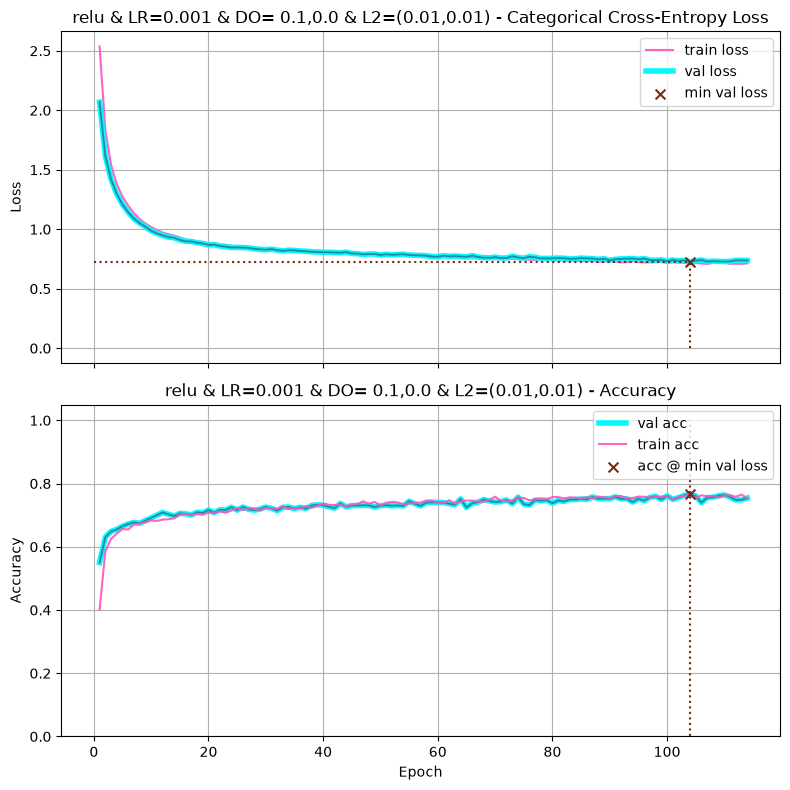

Final Training Loss:            0.7127
Final Training Accuracy:        0.7526
Final Validation Loss:          0.7380
Final Validation Accuracy:      0.7543
Minimum Validation Loss:        0.7243 (Epoch 104)
Validation Accuracy @ Min Loss: 0.7671

Test Loss: 0.7509
Test Accuracy: 0.7493

Validation-Test Gap (accuracy): 0.017857

Execution Time: 00:00:48


In [38]:
p5_mivl = []
p5_epml = []
p5_vacml = []
p5_title = []
p5_proc_dur = []

P1_best = 'relu'
p2_best = 1e-3

l2_reg = [1e-4, 1e-3, 1e-2]
dropout_to_test = [(0.2,0.0), (0.0,0.1), (0.1,0.0)]


for l2,(do1,do2) in product(l2_reg, dropout_to_test): 
    base_layer = [
        ##width--act--l2--DOrate##
        (64,    P1_best,  l2,       do1), 
        (32,    P1_best,  l2,       do2)
        ]
    proc_start = time.time()
    model_baseline = build_model(n_inputs, base_layer, n_classes)
    model_baseline_hx = train_and_test(
        model_baseline, 
        epochs        = 500,                   
        lr_schedule   = p2_best,                 
        optimizer     = "Adam",
        title         = f"{P1_best} & LR={p2_best} & DO= {do1},{do2} & L2=({l2},{l2})",
        batch_size    = 64,                     
        use_early_stopping = True,
        patience      = 10,                                       
        min_delta     = 0.0001,                 
        callbacks     = [],                    
        verbose       = 0,
        return_history = True
    )


    proc_end = time.time()


    min_val_loss = min(model_baseline_hx.history['val_loss'])
    epoch_loc_min_loss = model_baseline_hx.history['val_loss'].index(min_val_loss)
    val_acc_min_loss = (model_baseline_hx.history['val_accuracy'][epoch_loc_min_loss])


    p5_mivl.append(min_val_loss)
    p5_epml.append(epoch_loc_min_loss+1)
    p5_vacml.append(val_acc_min_loss)
    p5_title.append(f"{l2}*({do1},{do1})")
    p5_proc_dur.append(f"{format_hms(proc_end - proc_start)}")

    #---------------------------------------------------

p5_tab = pd.DataFrame({
    "type": "L2 * DO rate",
    "variable": p5_title,
    "min_loss_validation": p5_mivl,
    "epoch": p5_epml,
    "accuracy_validation": p5_vacml,
    "process_time": p5_proc_dur
})

# (p5_tab
#  .sort_values('accuracy_validation', ascending=False)
#  .round({'min_loss_validation':3, 'accuracy_validation':3})
# )




In [53]:
max(p5_tab['accuracy_validation'])

0.793571412563324

In [39]:

(p5_tab
 .sort_values('accuracy_validation', ascending=False)
 .round({'min_loss_validation':3, 'accuracy_validation':3})
)


,type,variable,min_loss_validation,epoch,accuracy_validation,process_time
0,L2 * DO rate,"0.0001*(0.2,0.2)",0.566,99,0.794,00:00:48
5,L2 * DO rate,"0.001*(0.1,0.1)",0.627,79,0.789,00:00:40
3,L2 * DO rate,"0.001*(0.2,0.2)",0.622,95,0.779,00:00:44
2,L2 * DO rate,"0.0001*(0.1,0.1)",0.593,53,0.771,00:00:29
4,L2 * DO rate,"0.001*(0.0,0.0)",0.670,41,0.770,00:00:25
1,L2 * DO rate,"0.0001*(0.0,0.0)",0.584,58,0.769,00:00:31
8,L2 * DO rate,"0.01*(0.1,0.1)",0.724,104,0.767,00:00:48
7,L2 * DO rate,"0.01*(0.0,0.0)",0.727,91,0.755,00:00:45
6,L2 * DO rate,"0.01*(0.2,0.2)",0.725,117,0.738,00:00:55


---

# p6

In [41]:
max(results.items(), key= lambda x:x[1][0])

('relu & LR=0.001 & DO= 0.2,0.0 & L2=(0.0001,0.0001)', (0.793571412563324, 99))

In [43]:
p5_l2_best , p5_do_combo = (
    p5_tab 
    .loc[p5_tab['accuracy_validation'].idxmax(), 'variable']
    .split("*")
)

p5_do1best, p5_do2best = (
    p5_do_combo.strip('()').split(',')
)

print(p5_do1best, p5_do2best)

0.2 0.2


In [51]:
if not(isinstance(P1_best, str)):
    print("yes")
else:
    print("no")

no



relu & LR=cosine 0.001 & DO= 0.2,0.2 & L2=(0.0001)



I0000 00:00:1789584029.598984    2817 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1811543__.18
I0000 00:00:1789584031.351342    2817 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1811543__.18


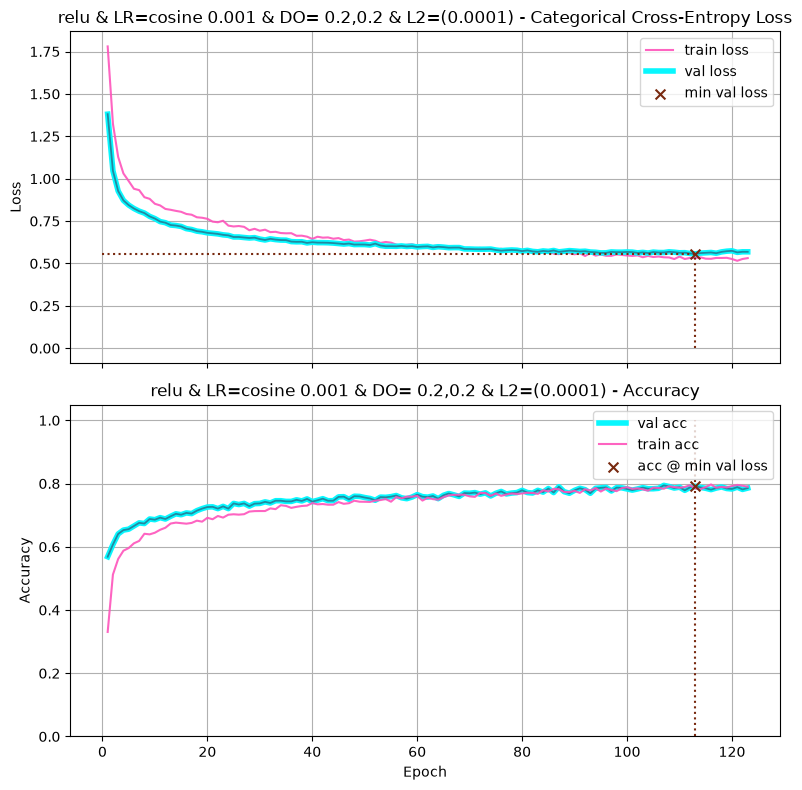

Final Training Loss:            0.5315
Final Training Accuracy:        0.7900
Final Validation Loss:          0.5686
Final Validation Accuracy:      0.7857
Minimum Validation Loss:        0.5565 (Epoch 113)
Validation Accuracy @ Min Loss: 0.7914

Test Loss: 0.6108
Test Accuracy: 0.7614

Validation-Test Gap (accuracy): 0.030000

Execution Time: 00:00:57


In [ ]:
from tensorflow.keras.optimizers.schedules import CosineDecay

p6_l2 = p5_tab
batch_size = 64
n_epoch = 500

steps_per_epoch = int(np.ceil(len(X_train) / batch_size))
total_steps = n_epoch * steps_per_epoch
lr_schedule = CosineDecay(
        initial_learning_rate= p2_best,
        decay_steps=total_steps,
        alpha=0.0  
    )

lr_schedule = ExponentialDecay(
	initial_learning_rate = 0.001
	, decay_steps = 1_000
	, decay_rate = 0.96
	, staircase = True
)


p5_l2_best , p5_do_combo = (
    p5_tab 
    .loc[p5_tab['accuracy_validation'].idxmax(), 'variable']
    .split("*")
)

p5_do1best, p5_do2best = (
    p5_do_combo.strip('()').split(',')
)

p5_l2_best = float(p5_l2_best)
p5_do1best = float(p5_do1best)
p5_do2best = float(p5_do2best)


p6_layer = [
        (64,    P1_best,  p5_l2_best,       p5_do1best), 
        (32,    P1_best,  p5_l2_best,       p5_do2best)
        ]
proc_start = time.time()
model_p6 = build_model(n_inputs, p6_layer, n_classes)
model_p6_hx = train_and_test(
    model_p6, 
    epochs        = 500,                   
    lr_schedule   = lr_schedule,                 
    optimizer     = "Adam",
    title         = f"{P1_best} & LR=cosine {p2_best} & DO= {p5_do1best},{p5_do2best} & L2=({p5_l2_best})",
    batch_size    = 64,                     
    use_early_stopping = True,
    patience      = 10,                                       
    min_delta     = 0.0001,                 
    callbacks     = [],                    
    verbose       = 0,
    return_history = True
)


proc_end = time.time()